In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
healthy_data = pd.read_csv("healthy_data.csv")
damaged_data = pd.read_csv("damaged_data.csv")

In [3]:
healthy_data['State'] = 1 # one means healthy
damaged_data['State'] = 0 # zero means damaged

In [4]:
healthy_data.columns = healthy_data.columns.str.replace('H', 'S')
damaged_data.columns = damaged_data.columns.str.replace('D', 'S')

In [5]:
common_cols = healthy_data.columns.intersection(damaged_data.columns)
new_healthy_data = healthy_data[common_cols]
new_damage_data = damaged_data[common_cols]

In [7]:
dfGbxData = pd.concat([new_healthy_data, new_damage_data]).reset_index()

In [8]:
dfGbxData.to_csv('all_gbx_data_raw.csv')

In [10]:
# Normalize features
from sklearn.preprocessing import StandardScaler
features = dfGbxData.columns
scaler = StandardScaler()
data_scaled = scaler.fit_transform(dfGbxData[features[1:-1]])

array([[-3.69431185e-01,  3.08187012e-01, -7.39451009e-01, ...,
         3.17591683e-02,  6.69520346e-01, -1.00009848e+00],
       [-6.34323738e-01,  4.00644134e-01, -9.48070642e-01, ...,
         1.28030830e-02,  4.04866287e-01, -1.00009841e+00],
       [-9.63711957e-01, -8.67584018e-02, -1.06625913e+00, ...,
        -1.46262862e-03,  4.17429882e-01, -1.00009843e+00],
       ...,
       [-3.24265240e+00,  8.92235493e-01,  1.03848523e+00, ...,
         5.22331879e-01, -8.67248960e-01,  1.00010650e+00],
       [-3.45405489e+00,  8.88447526e-01,  1.66176790e+00, ...,
        -7.13116799e-01, -1.07054259e+00,  1.00031592e+00],
       [-3.19558680e+00,  1.02518828e+00,  1.95664031e+00, ...,
        -1.06700675e+00, -1.07992347e+00,  1.00033786e+00]])

In [13]:
data_scaled = pd.DataFrame(data_scaled, columns=dfGbxData.columns[1:-1])
data_scaled['State'] = dfGbxData['State']
data_scaled.head()

,S1_AN3,S1_AN4,S1_AN5,S1_AN6,S1_AN7,S1_AN8,S1_AN9,S1_AN10,S1_Speed,S10_AN3,...,S9_AN3,S9_AN4,S9_AN5,S9_AN6,S9_AN7,S9_AN8,S9_AN9,S9_AN10,S9_Speed,State
0,-0.369431,0.308187,-0.739451,-0.524874,1.357016,-0.473188,-0.390907,-0.154307,-1.000099,-0.152254,...,-0.499683,-0.378666,-0.404995,-0.727901,0.496784,0.356024,0.031759,0.669520,-1.000098,1
1,-0.634324,0.400644,-0.948071,-0.399580,1.214408,-0.506659,-0.471283,0.049007,-1.000099,0.160816,...,-0.512779,-0.560482,-0.335487,-0.918227,-0.993746,0.271797,0.012803,0.404866,-1.000098,1
2,-0.963712,-0.086758,-1.066259,0.840456,-0.219053,-0.231510,-0.542011,0.135518,-1.000099,0.202967,...,-0.265210,-0.799033,-0.204492,-0.305016,-0.103271,0.290064,-0.001463,0.417430,-1.000098,1
3,-1.224967,0.128320,-0.987579,0.658703,-0.120566,-0.329965,-0.601701,-0.003422,-1.000099,0.378524,...,-0.128843,-1.428618,-0.082010,-0.655027,0.321801,0.071663,-0.006809,0.476999,-1.000098,1
4,-1.214718,0.628594,-0.768050,0.267174,-0.403716,-0.404129,-0.641022,0.021500,-1.000099,0.339021,...,-0.264725,-1.625296,-0.249487,-0.599866,0.146248,0.050971,-0.000539,0.675822,-1.000098,1


In [18]:
dfGbxData = pd.read_csv('all_gbx_data_raw.csv')

In [ ]:
data_scaled.to_csv('all_gbx_data_scaled.csv')

In [5]:
data_scaled = pd.read_csv('all_gbx_data_raw.csv')

In [6]:
data_scaled.head()

,Unnamed: 0,index,S1_AN3,S1_AN4,S1_AN5,S1_AN6,S1_AN7,S1_AN8,S1_AN9,S1_AN10,...,S9_AN3,S9_AN4,S9_AN5,S9_AN6,S9_AN7,S9_AN8,S9_AN9,S9_AN10,S9_Speed,State
0,0,0,-0.823841,0.749480,-2.316878,-1.960000,4.391394,-3.048822,-2.294245,-0.485538,...,-1.090296,-0.904247,-1.351590,-2.845421,1.663906,2.327122,-0.063827,2.123119,0.000569,1
1,1,1,-1.402680,0.977488,-2.939493,-1.525210,3.927973,-3.260050,-2.718662,0.146392,...,-1.118411,-1.333007,-1.139149,-3.552332,-3.391658,1.761173,-0.164418,1.281423,0.000632,1
2,2,2,-2.122453,-0.224492,-3.292221,2.777935,-0.730244,-1.523624,-3.092139,0.415281,...,-0.586930,-1.895562,-0.738779,-1.274737,-0.371353,1.883912,-0.240120,1.321379,0.000610,1
3,3,3,-2.693342,0.305910,-3.057404,2.147219,-0.410198,-2.144959,-3.407326,-0.016563,...,-0.294178,-3.380255,-0.364430,-2.574751,1.070402,0.416392,-0.268491,1.510831,0.000581,1
4,4,4,-2.670948,1.539633,-2.402231,0.788547,-1.330330,-2.612996,-3.614957,0.060899,...,-0.585888,-3.844061,-0.876301,-2.369874,0.474962,0.277355,-0.235219,2.143160,0.000596,1


In [11]:
data_scaled.columns[2:-1]

Index(['S1_AN3', 'S1_AN4', 'S1_AN5', 'S1_AN6', 'S1_AN7', 'S1_AN8', 'S1_AN9',
       'S1_AN10', 'S1_Speed', 'S10_AN3', 'S10_AN4', 'S10_AN5', 'S10_AN6',
       'S10_AN7', 'S10_AN8', 'S10_AN9', 'S10_AN10', 'S10_Speed', 'S2_AN3',
       'S2_AN4', 'S2_AN5', 'S2_AN6', 'S2_AN7', 'S2_AN8', 'S2_AN9', 'S2_AN10',
       'S2_Speed', 'S3_AN3', 'S3_AN4', 'S3_AN5', 'S3_AN6', 'S3_AN7', 'S3_AN8',
       'S3_AN9', 'S3_AN10', 'S3_Speed', 'S4_AN3', 'S4_AN4', 'S4_AN5', 'S4_AN6',
       'S4_AN7', 'S4_AN8', 'S4_AN9', 'S4_AN10', 'S4_Speed', 'S5_AN3', 'S5_AN4',
       'S5_AN5', 'S5_AN6', 'S5_AN7', 'S5_AN8', 'S5_AN9', 'S5_AN10', 'S5_Speed',
       'S6_AN3', 'S6_AN4', 'S6_AN5', 'S6_AN6', 'S6_AN7', 'S6_AN8', 'S6_AN9',
       'S6_AN10', 'S6_Speed', 'S7_AN3', 'S7_AN4', 'S7_AN5', 'S7_AN6', 'S7_AN7',
       'S7_AN8', 'S7_AN9', 'S7_AN10', 'S7_Speed', 'S8_AN3', 'S8_AN4', 'S8_AN5',
       'S8_AN6', 'S8_AN7', 'S8_AN8', 'S8_AN9', 'S8_AN10', 'S8_Speed', 'S9_AN3',
       'S9_AN4', 'S9_AN5', 'S9_AN6', 'S9_AN7', 'S9_AN8', 'S9

In [ ]:
feature_cols = data_scaled.columns[2:-1]  # all columns except first and last one (assuming it's 'State')

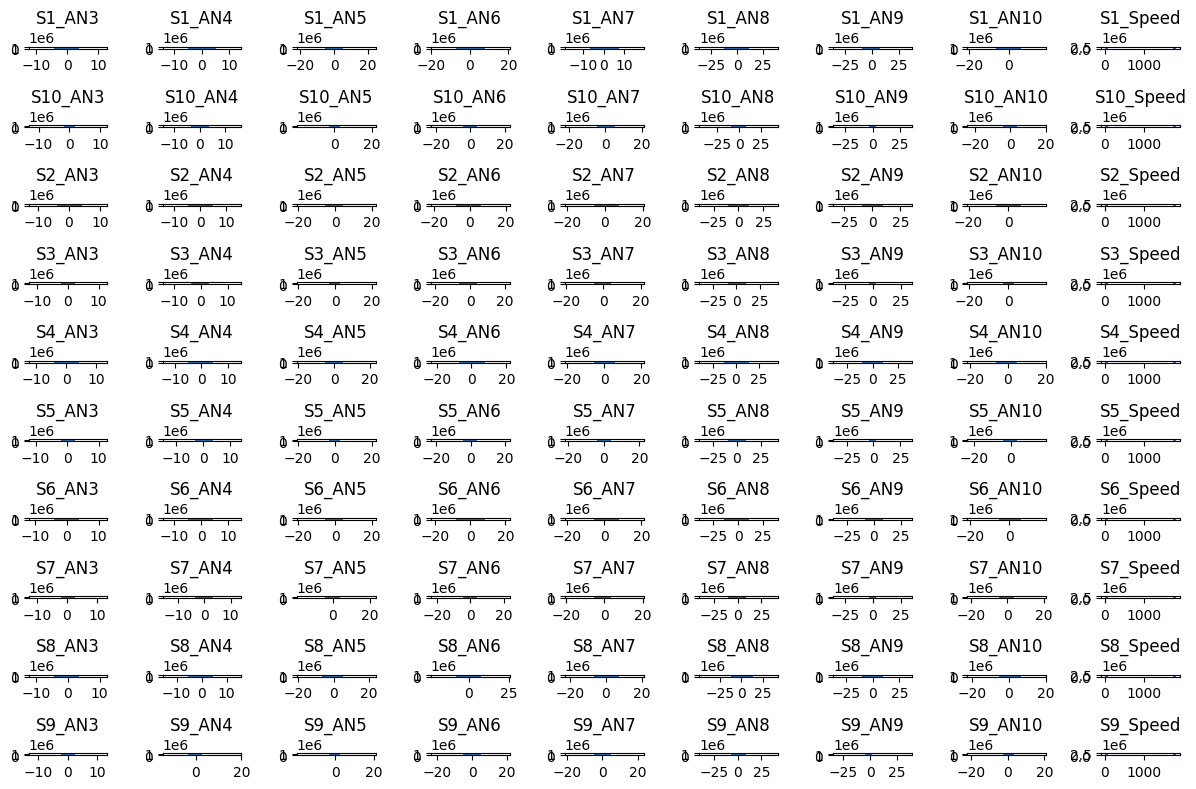

In [19]:
dfGbxData[feature_cols].hist(bins=20, figsize=(12, 8), grid=False)
plt.tight_layout()
plt.show()

c:\users\anand.khare\documents\learnings\venv\lib\site-packages\seaborn\axisgrid.py:453: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=figsize)


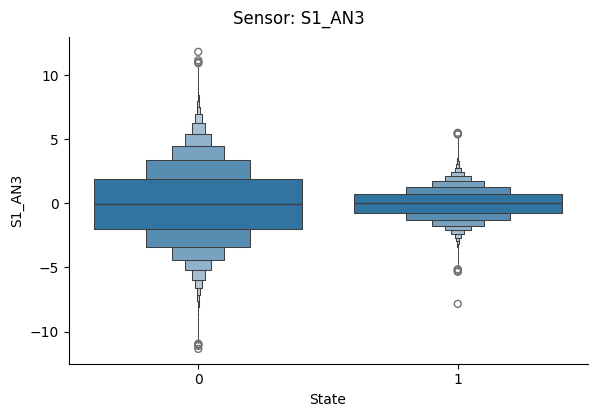

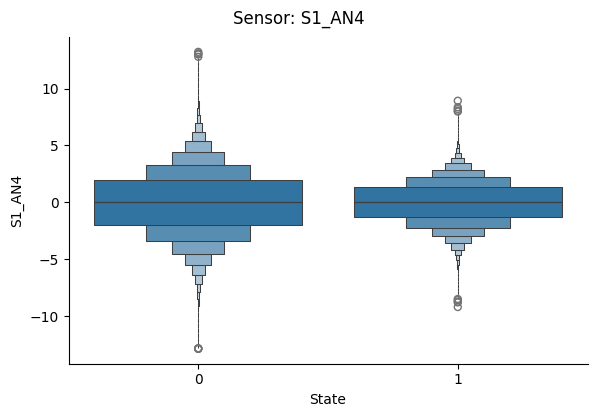

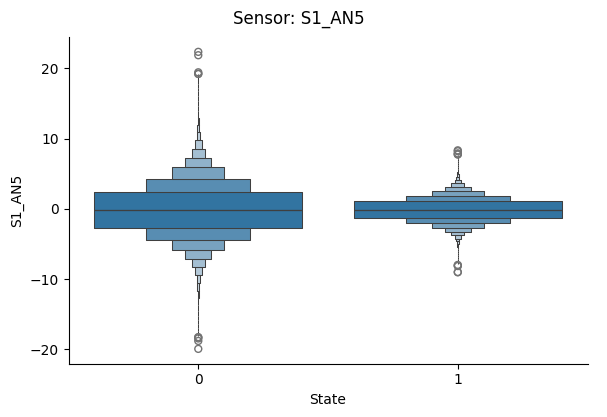

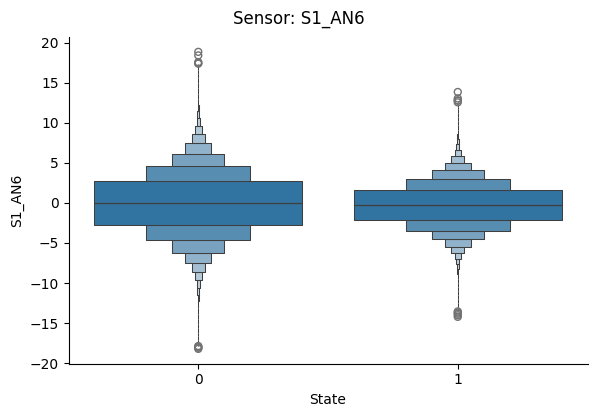

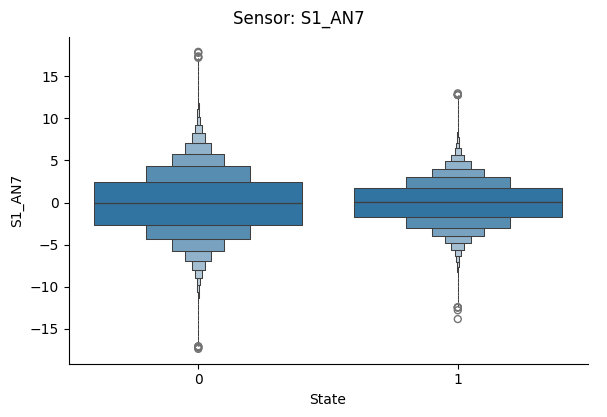

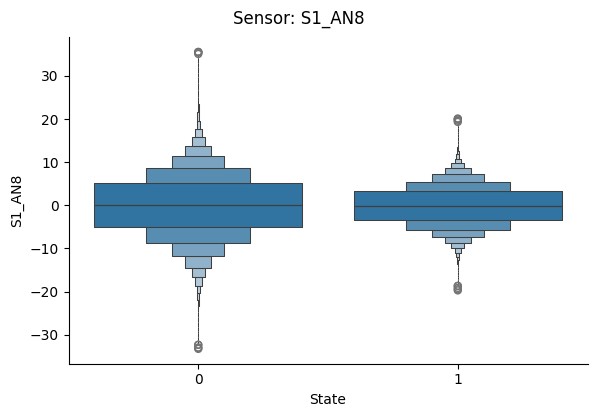

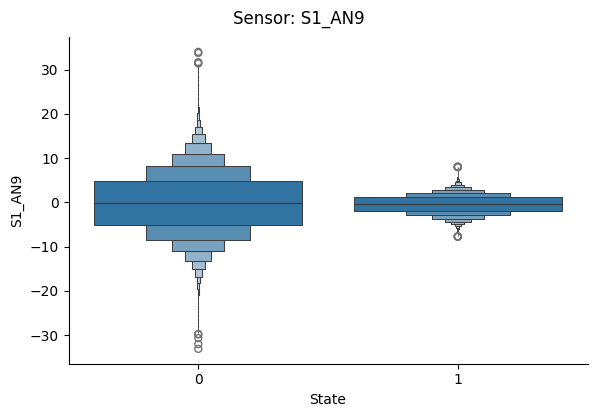

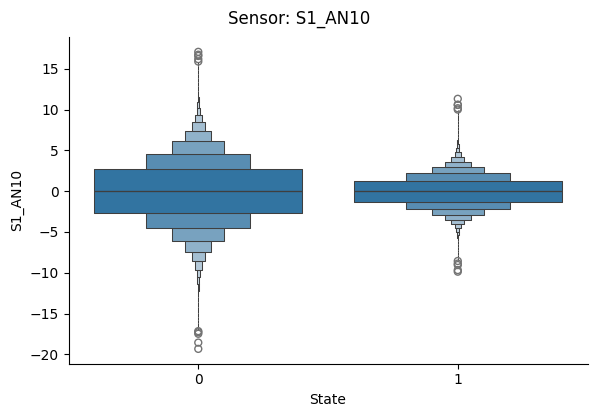

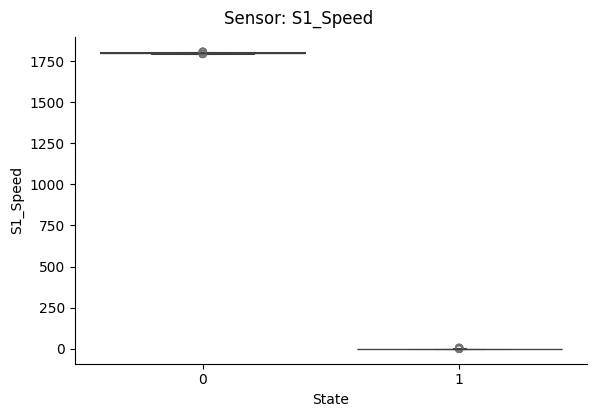

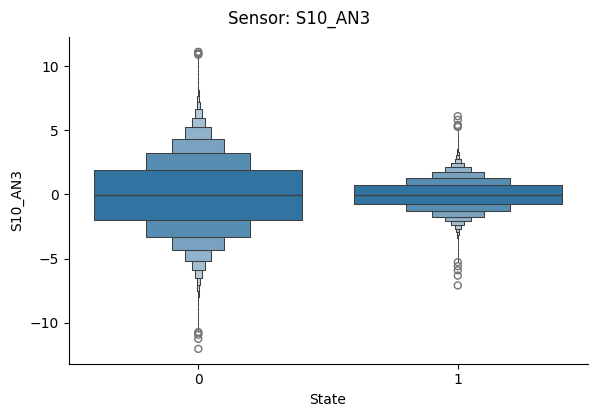

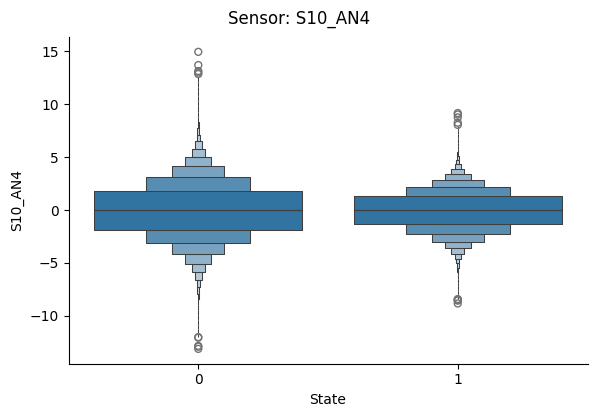

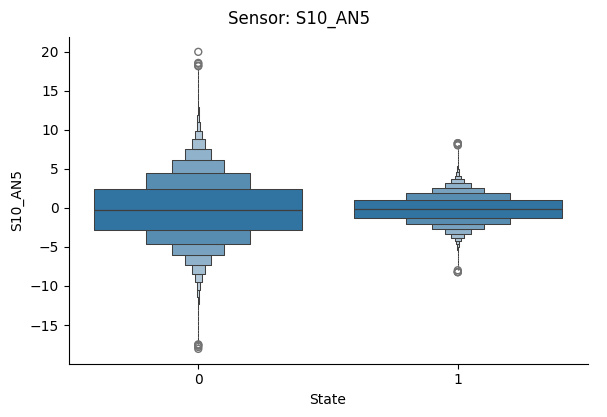

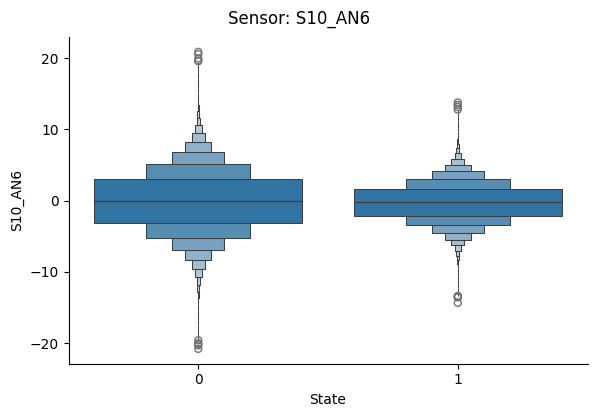

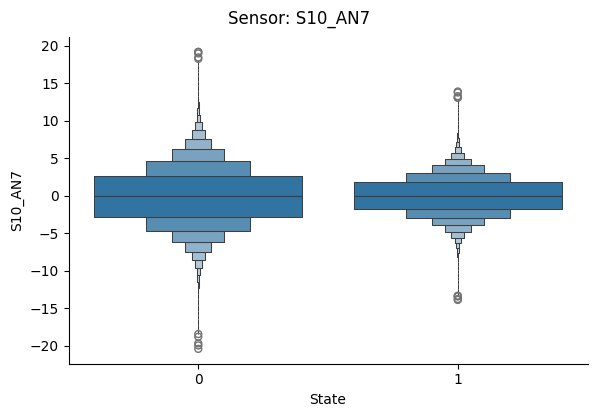

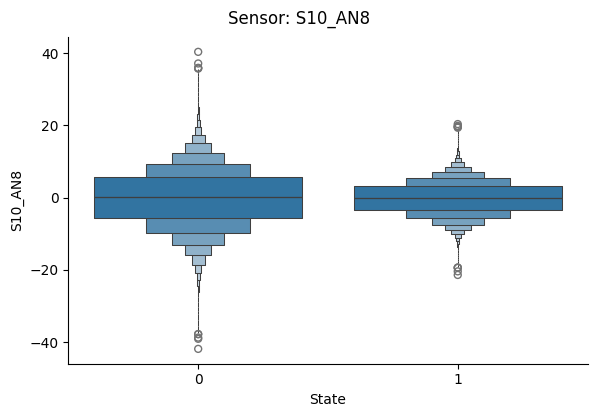

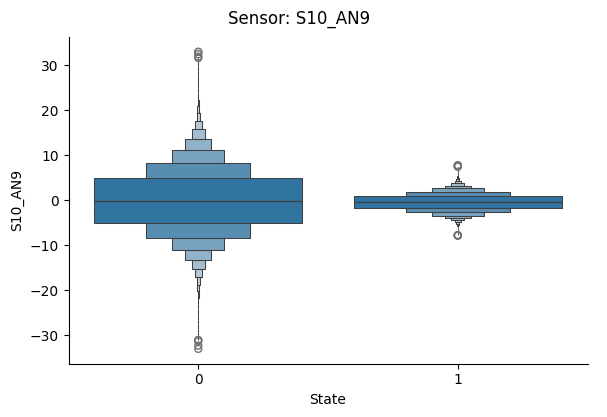

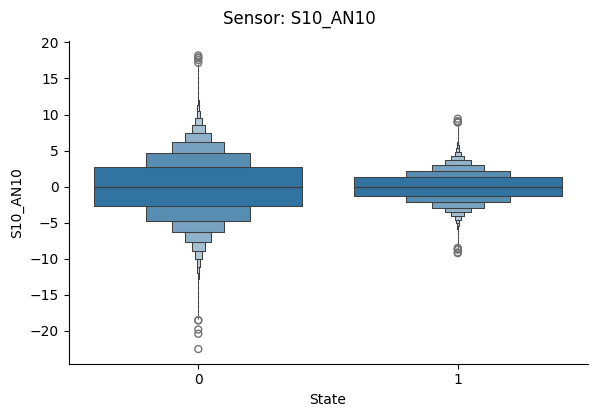

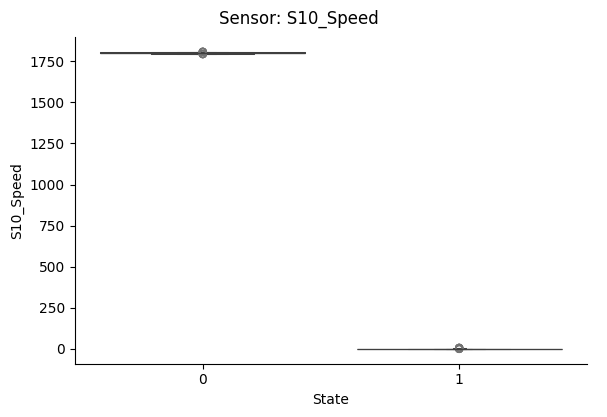

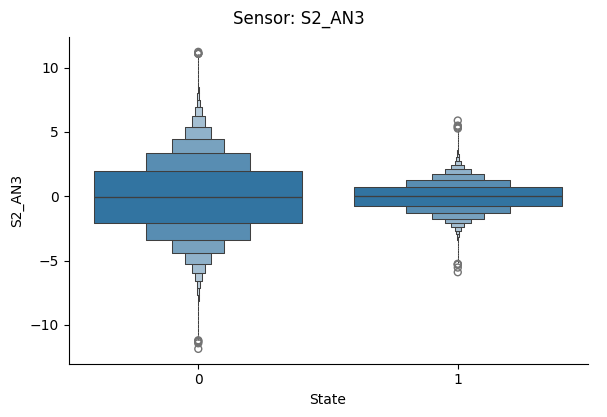

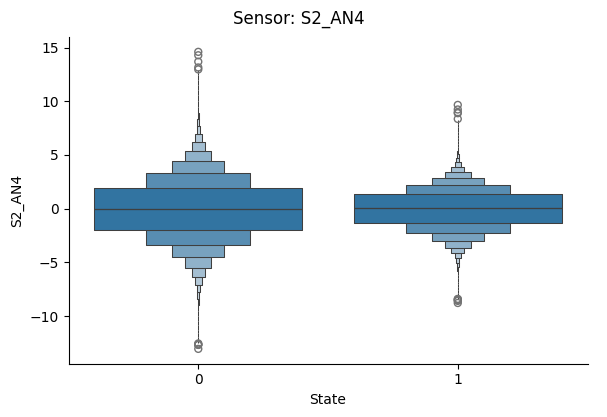

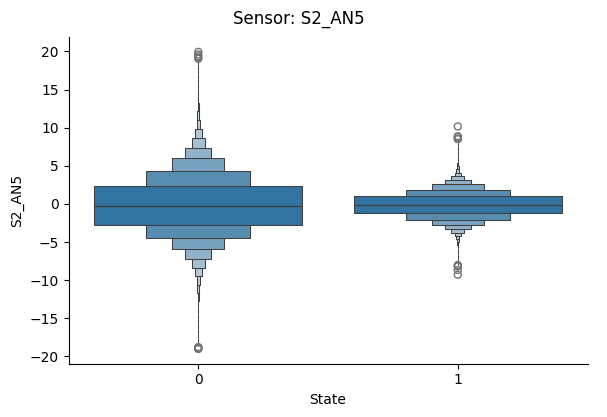

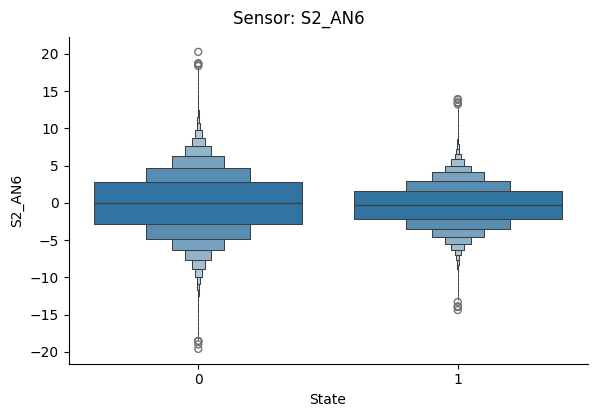

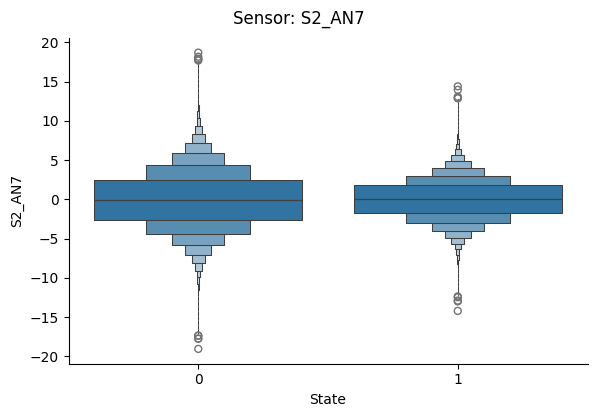

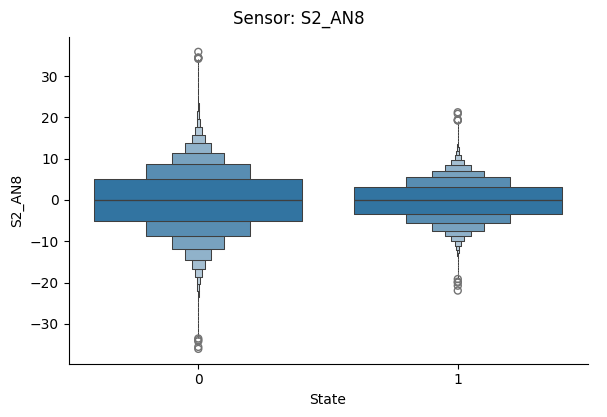

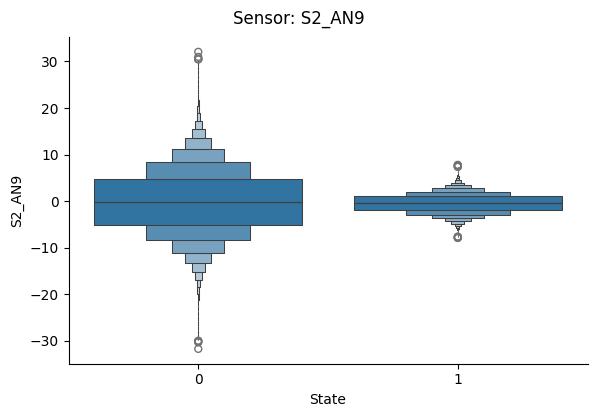

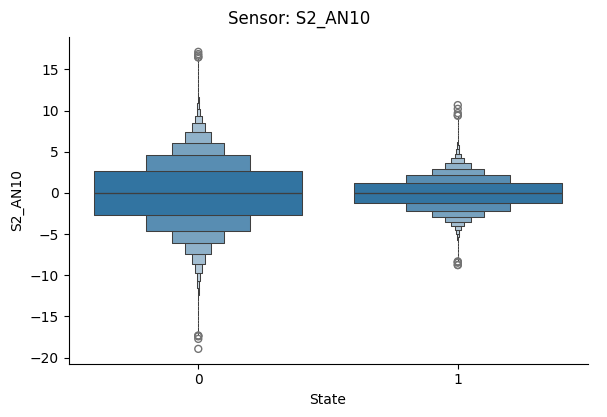

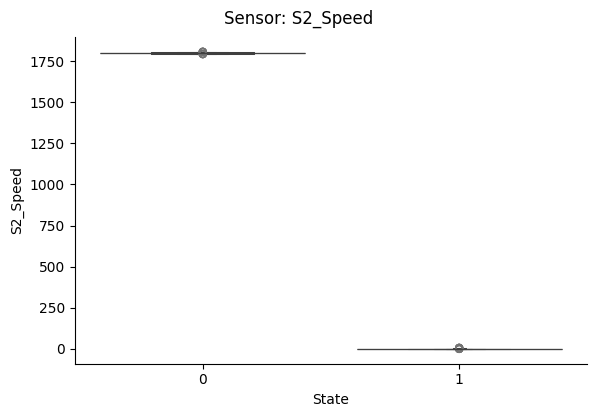

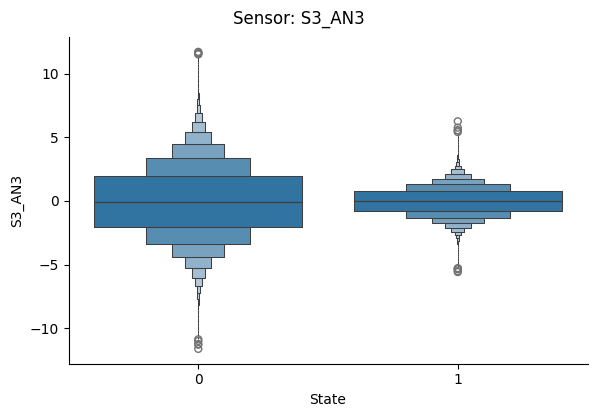

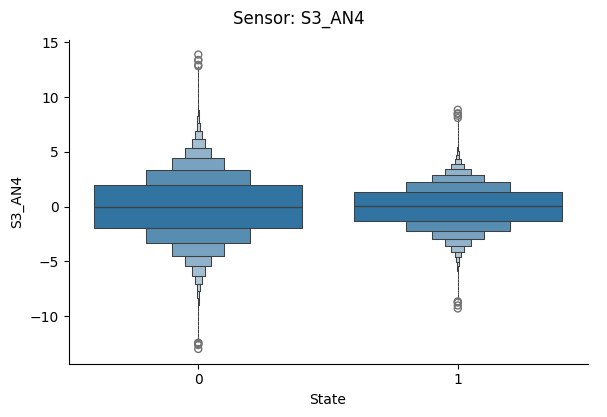

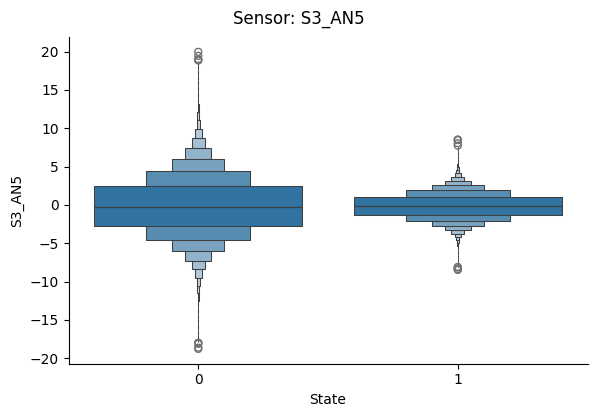

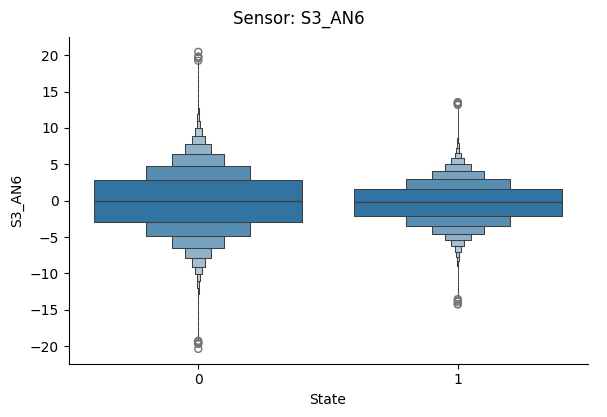

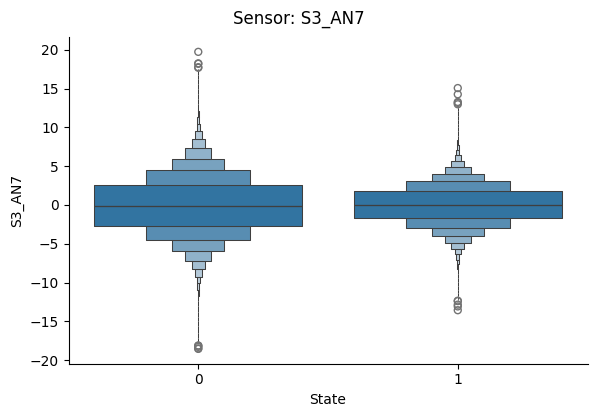

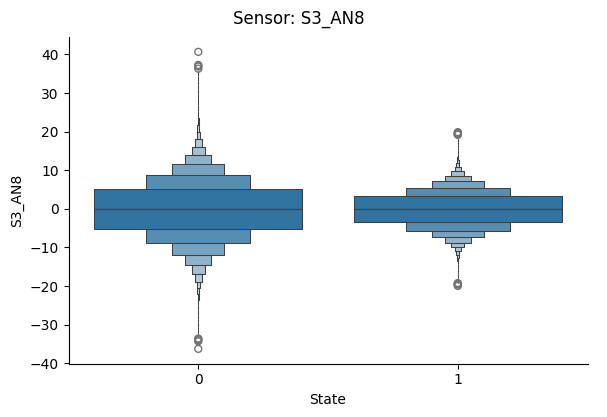

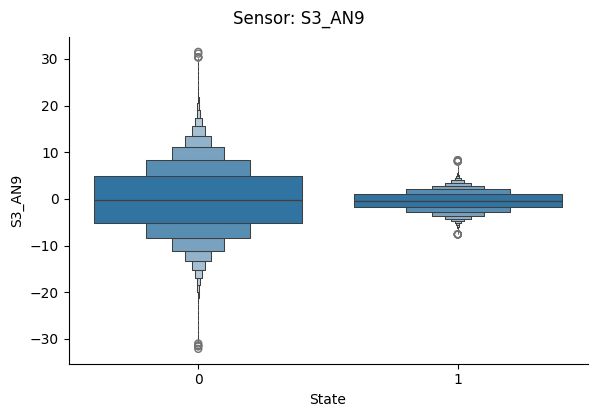

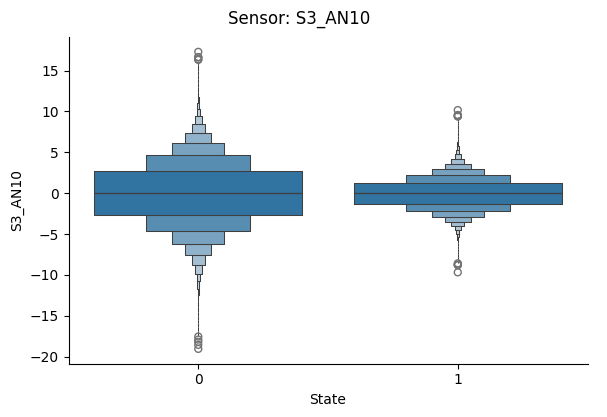

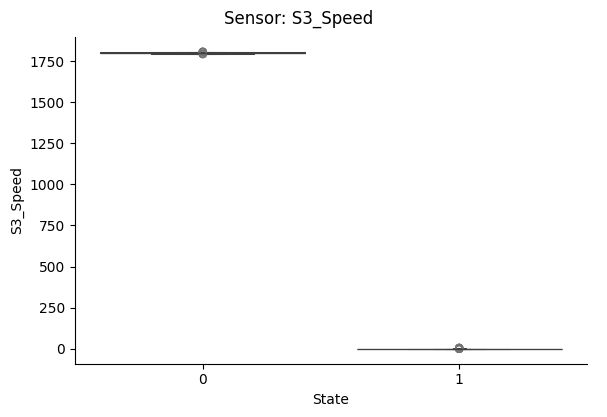

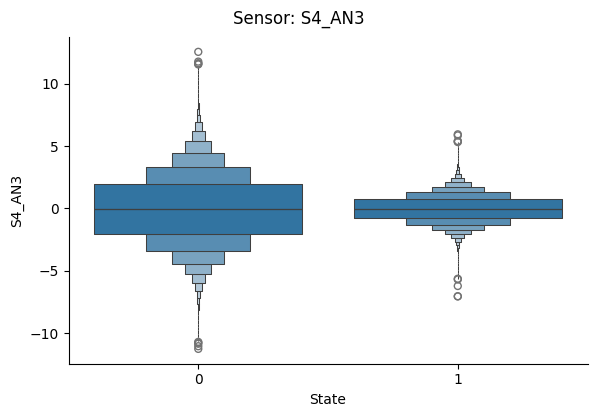

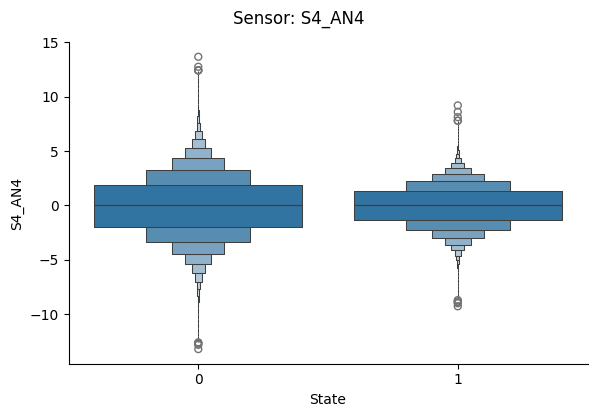

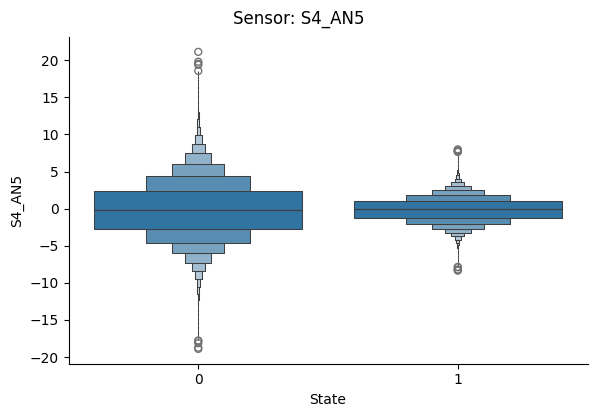

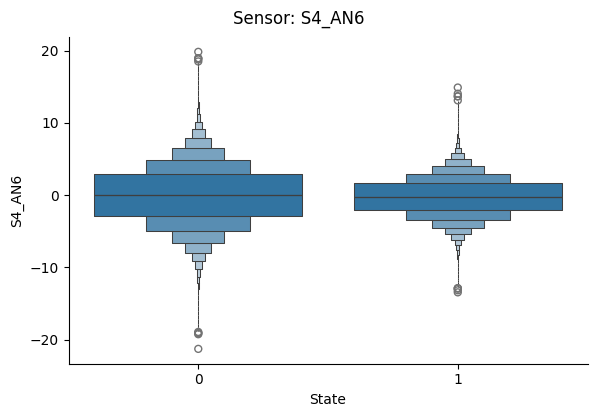

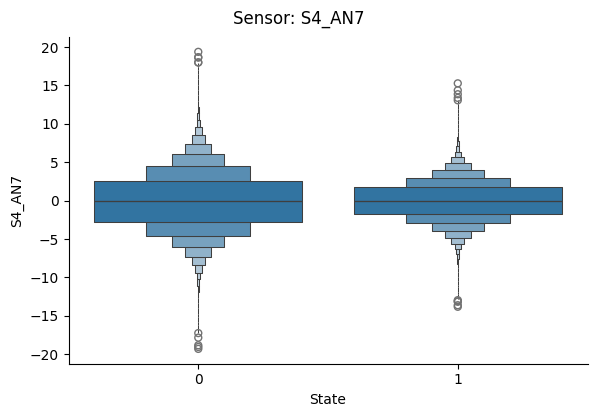

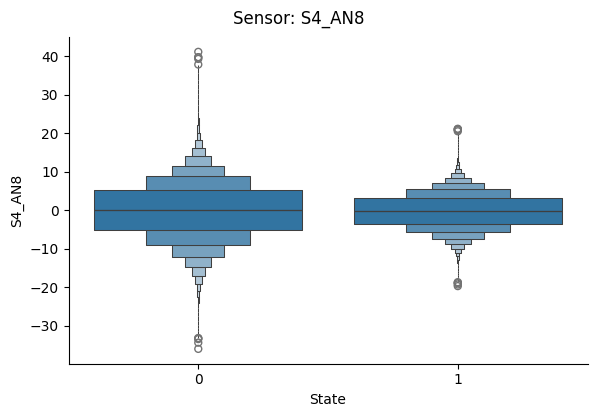

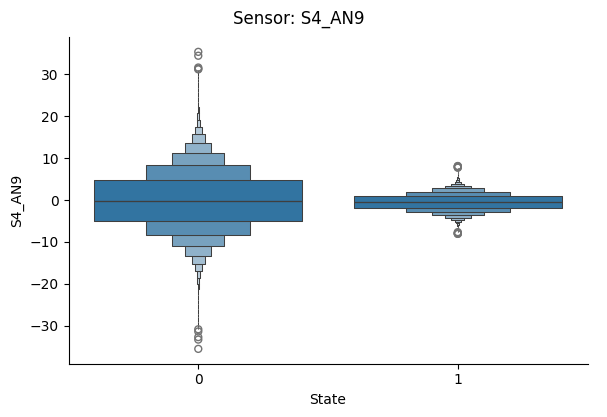

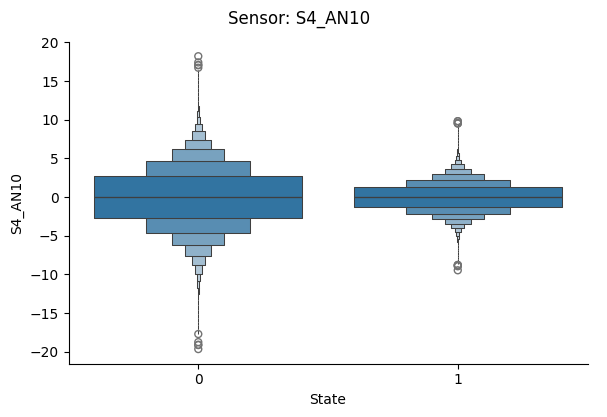

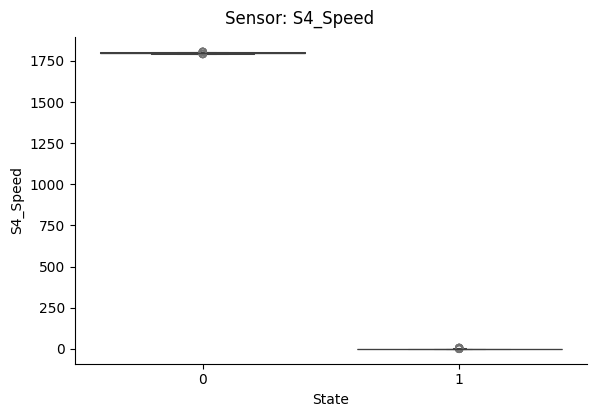

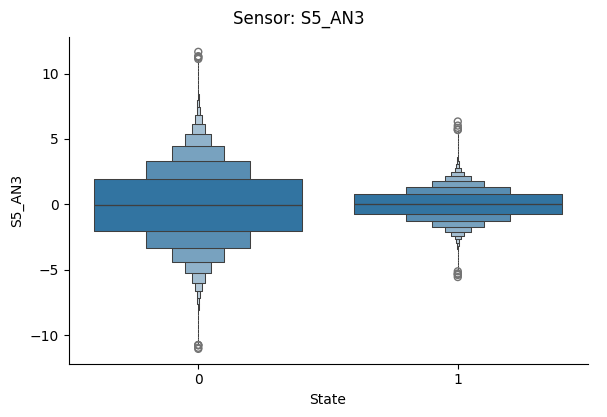

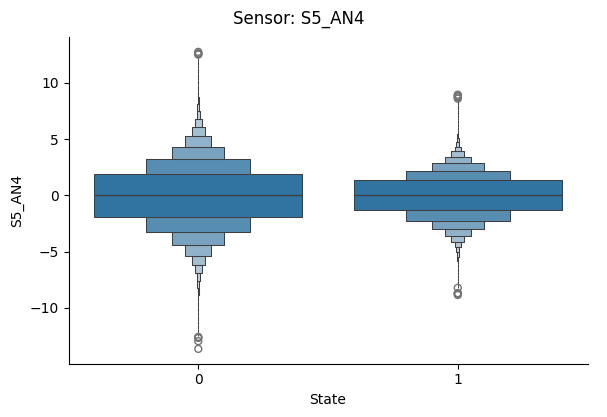

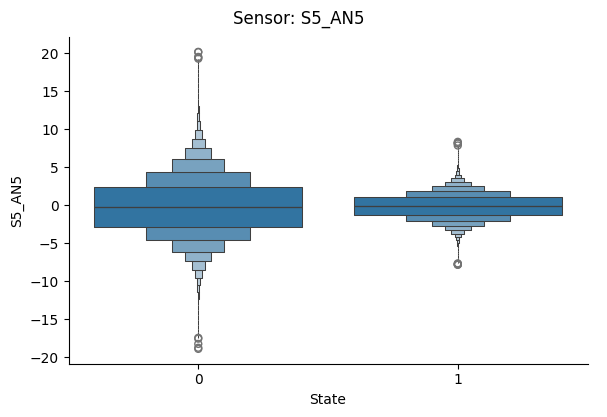

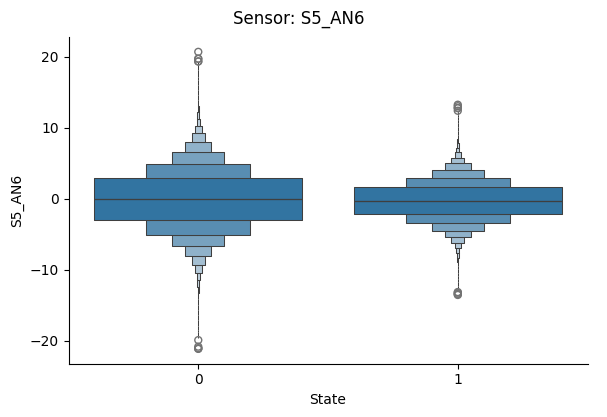

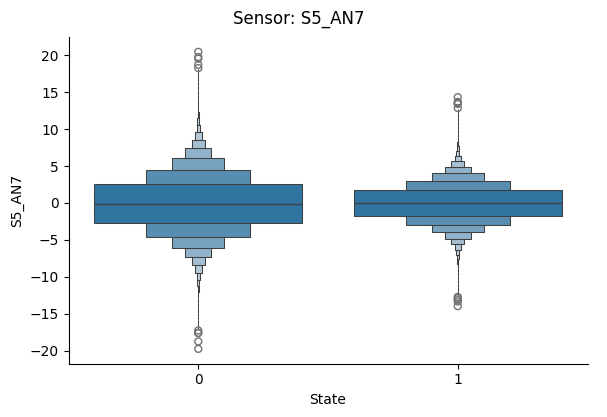

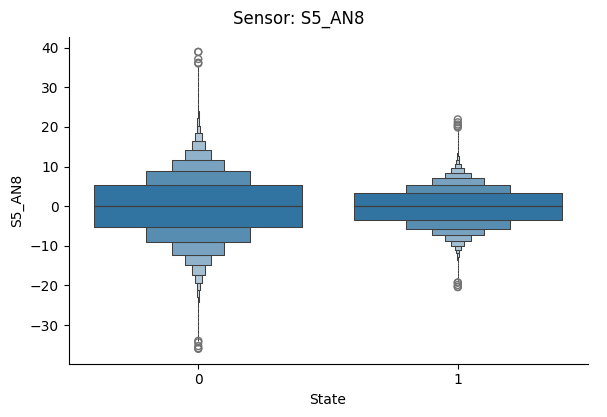

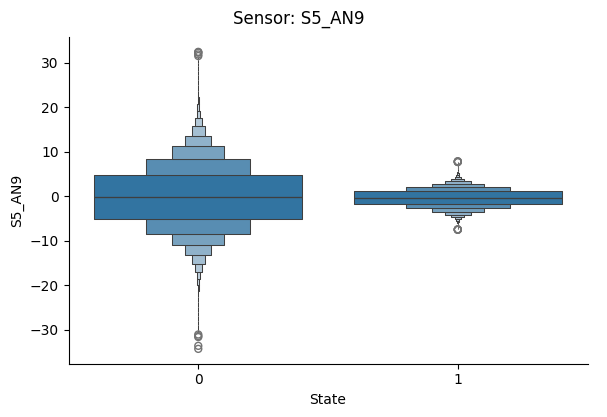

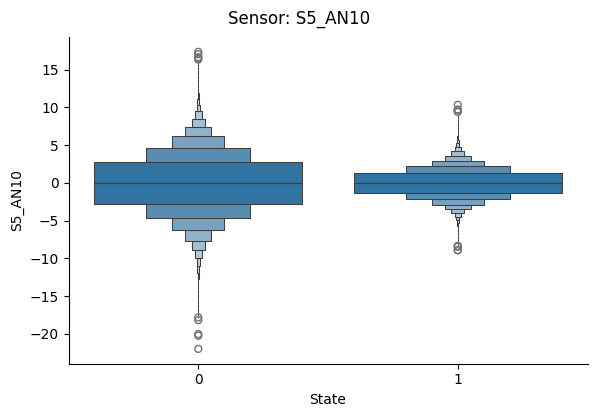

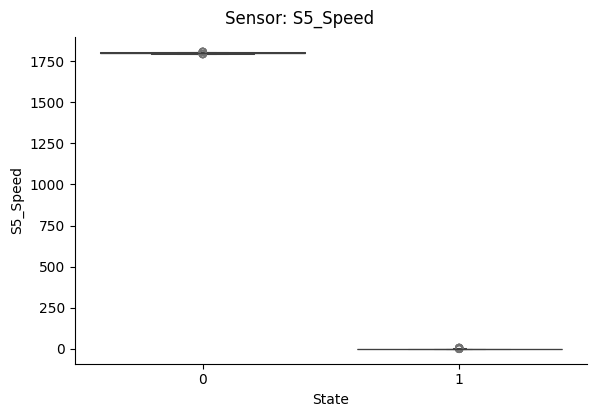

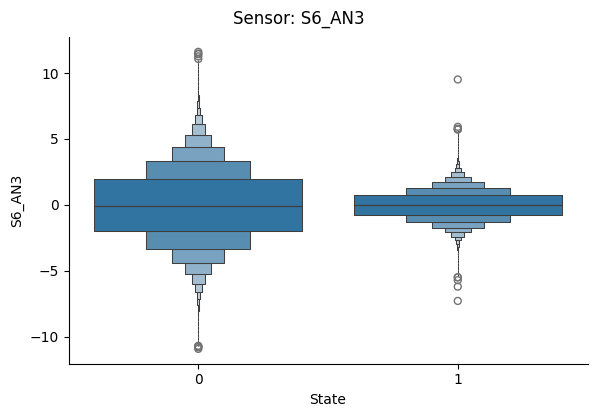

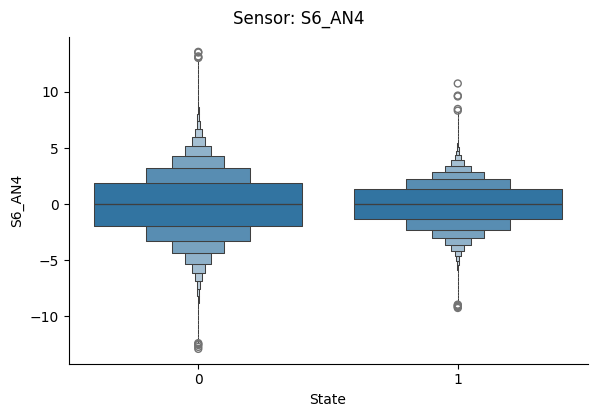

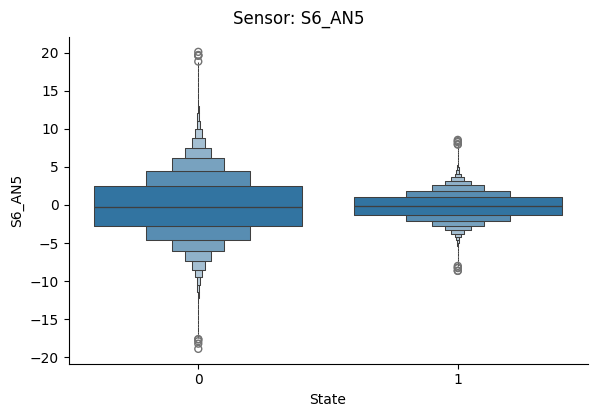

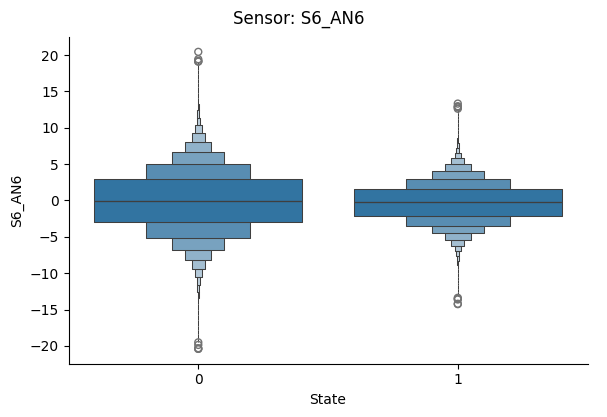

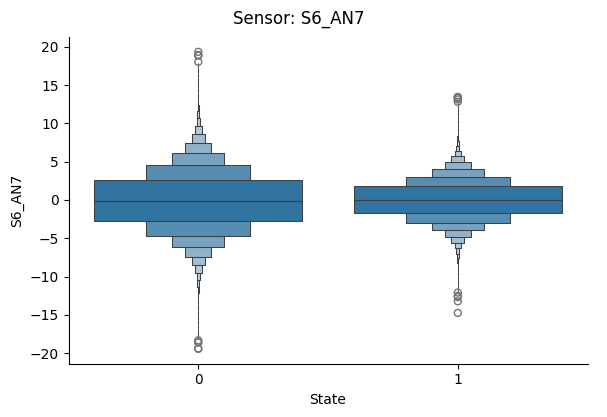

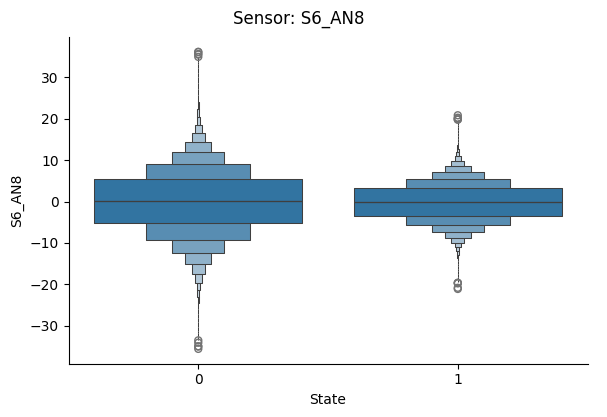

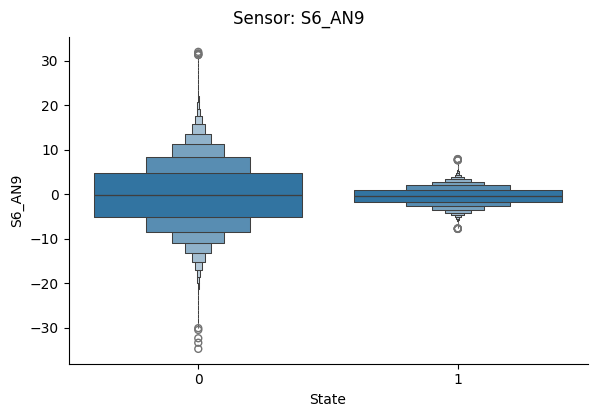

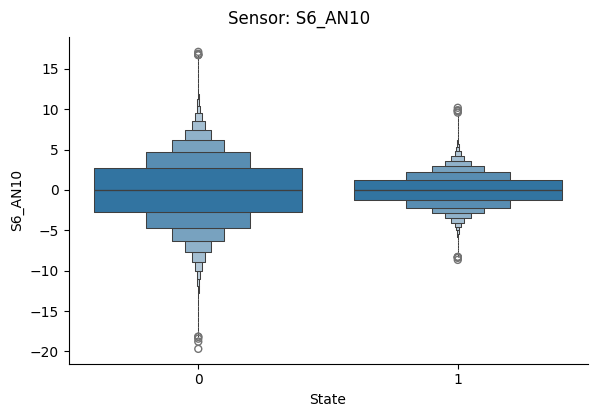

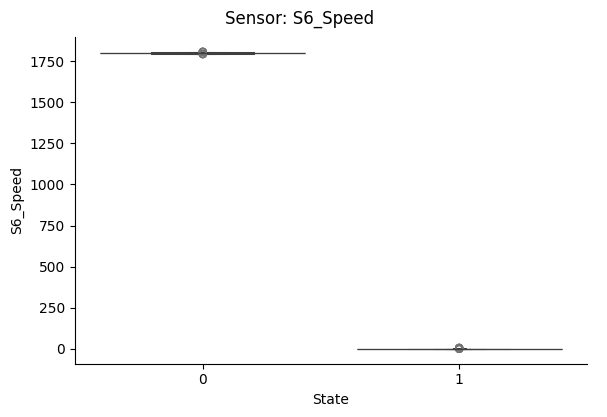

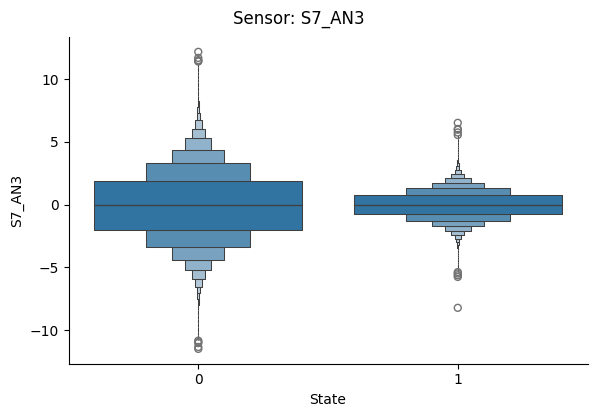

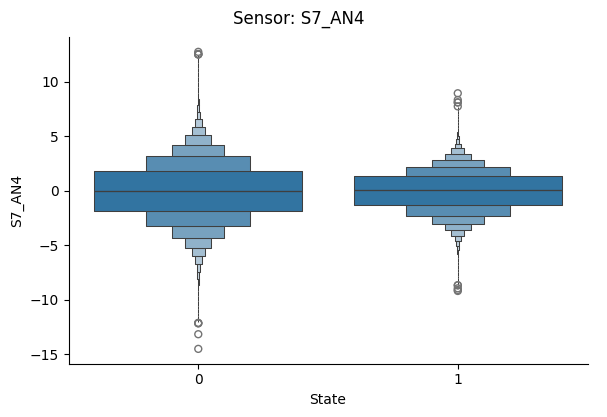

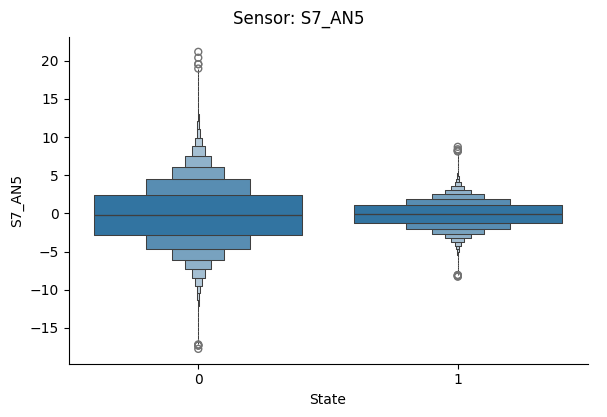

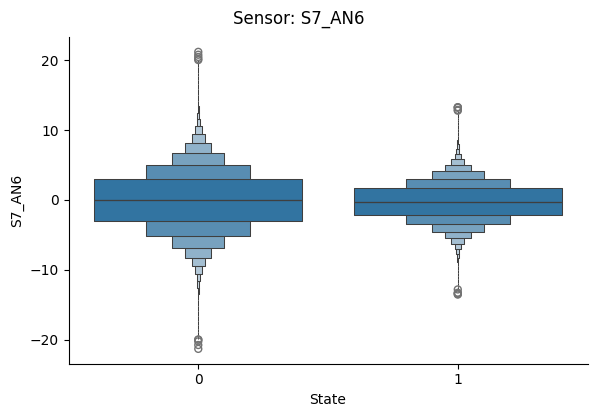

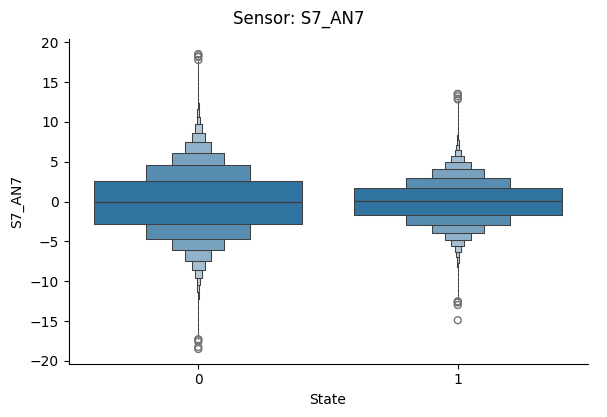

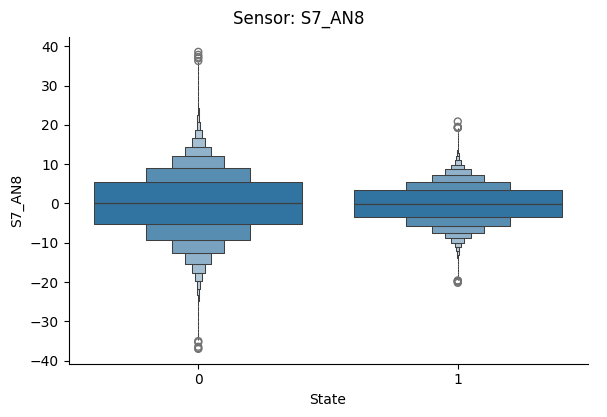

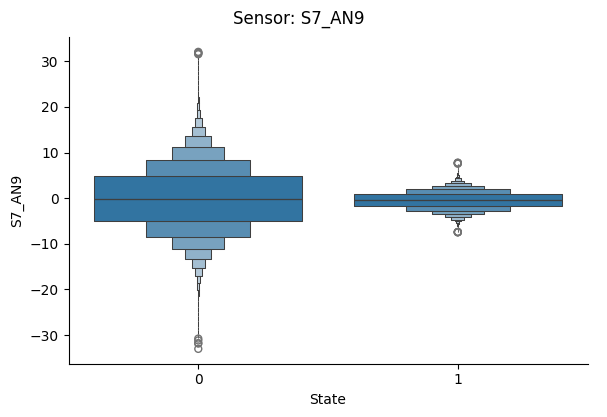

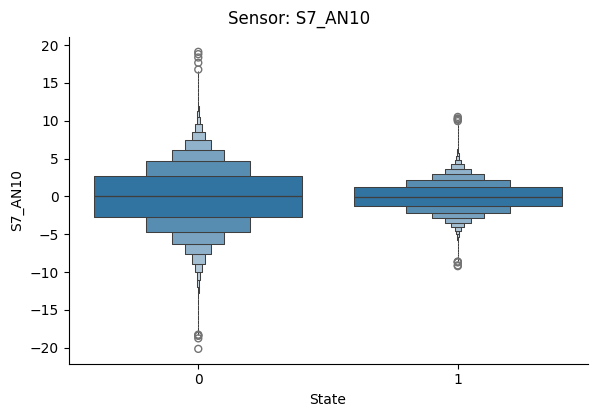

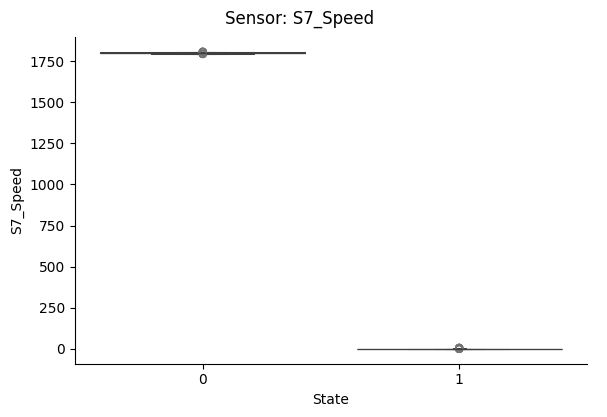

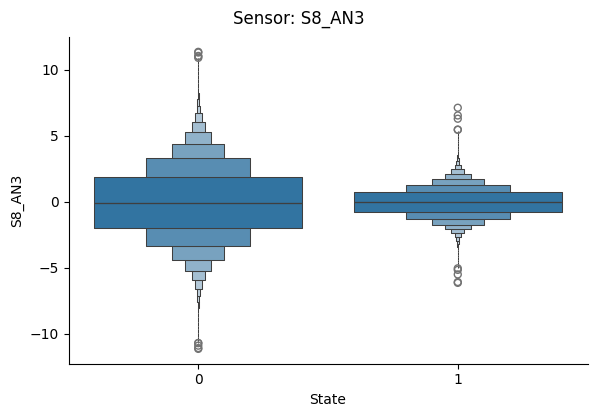

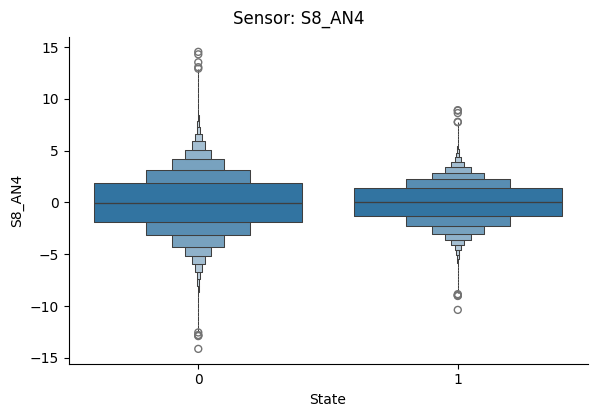

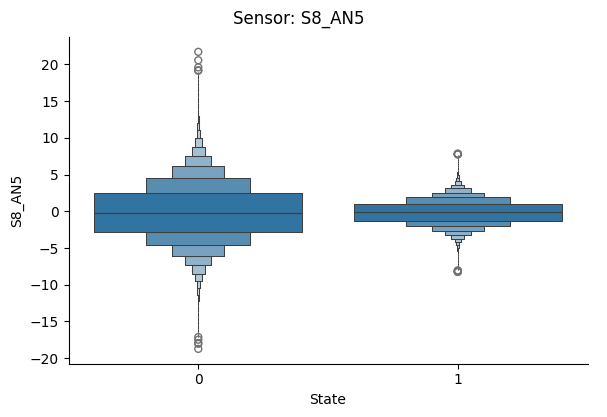

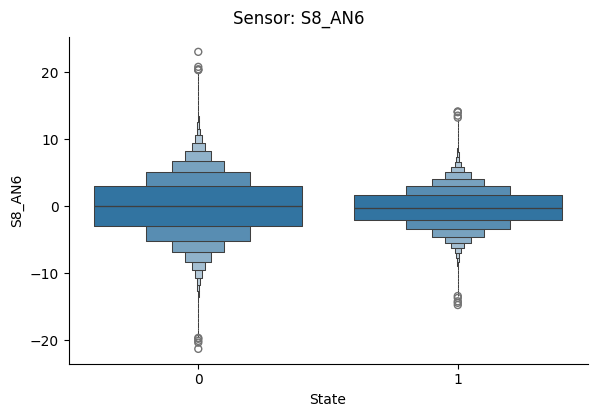

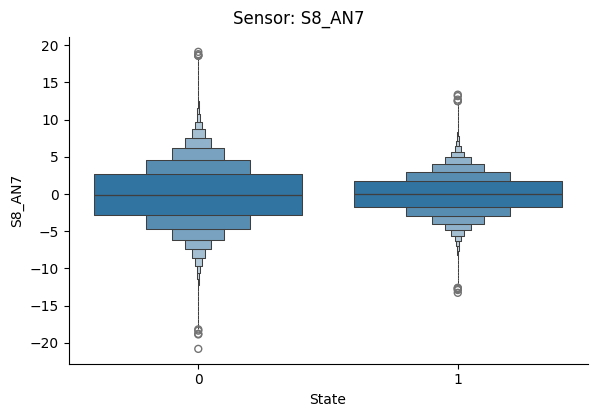

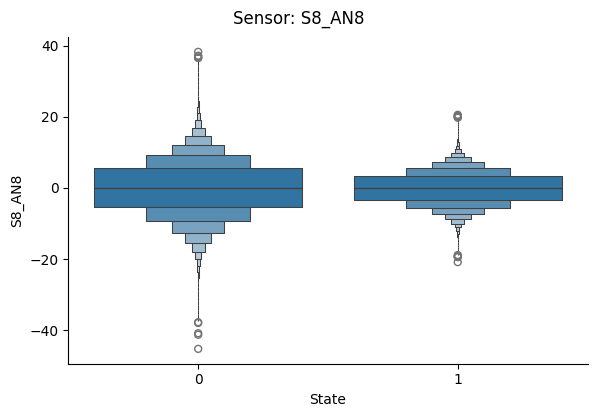

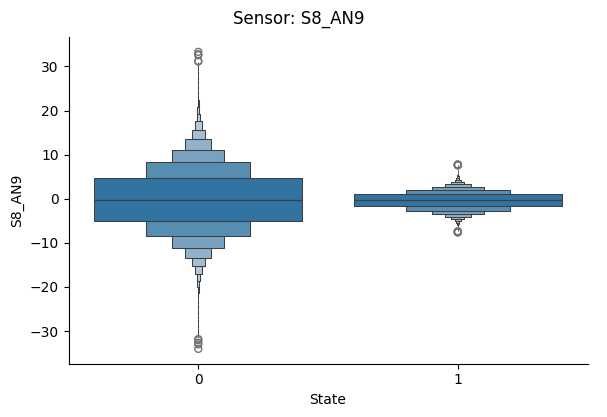

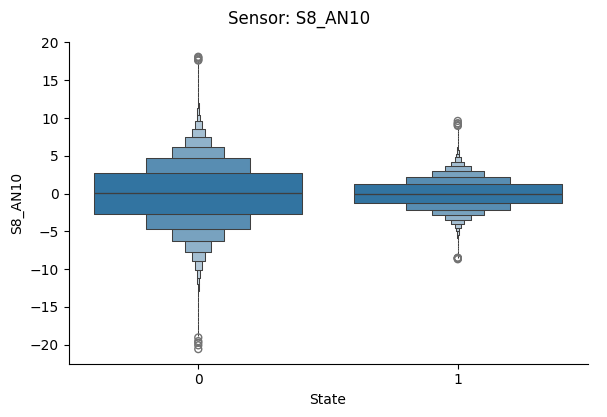

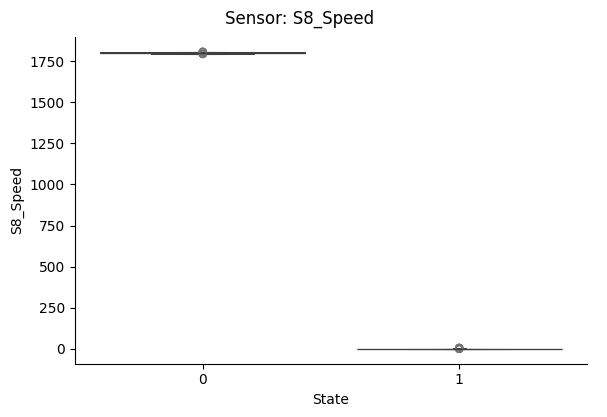

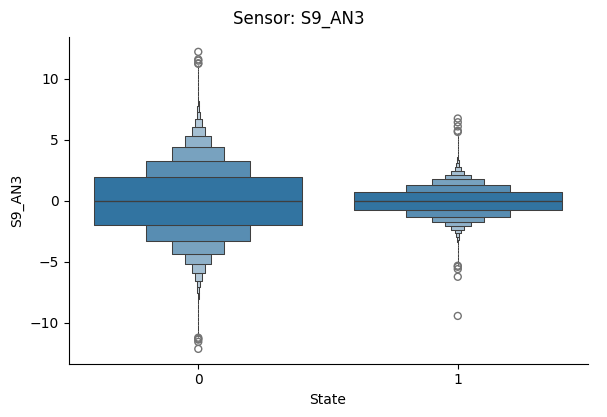

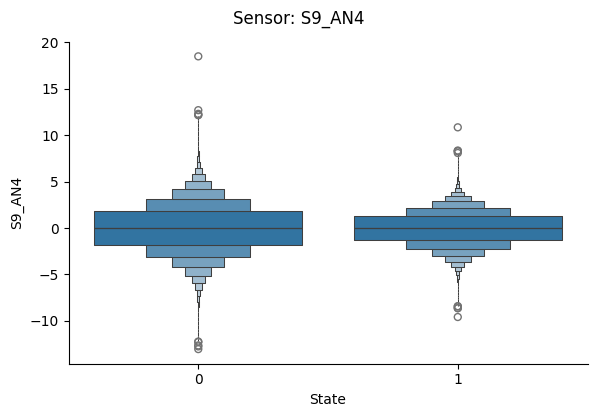

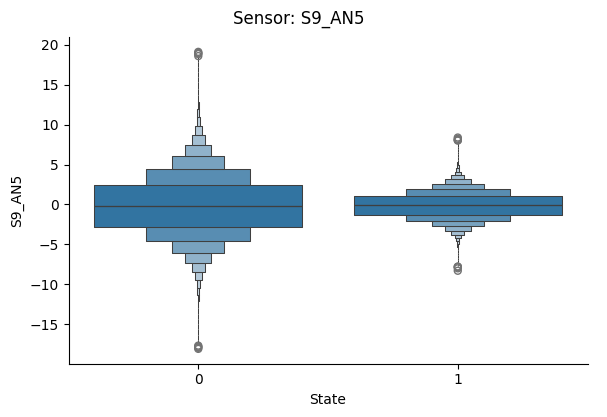

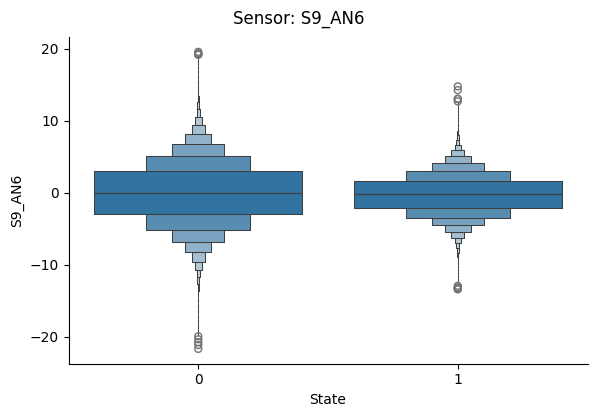

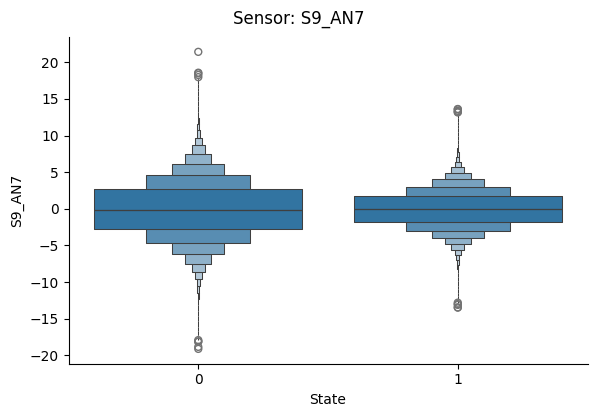

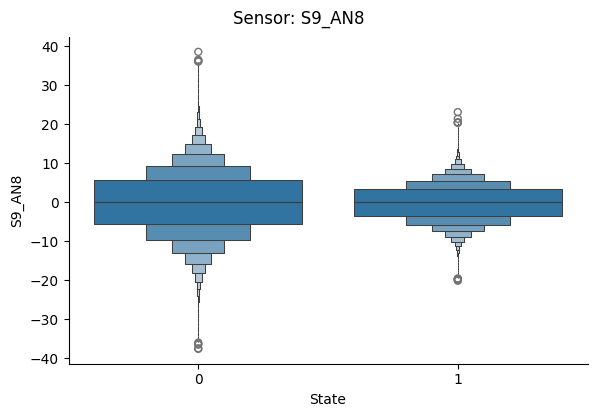

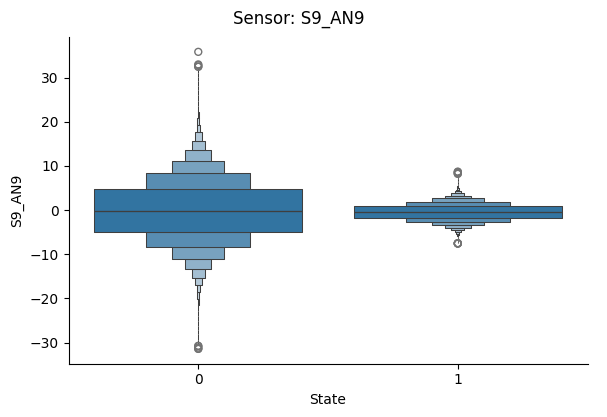

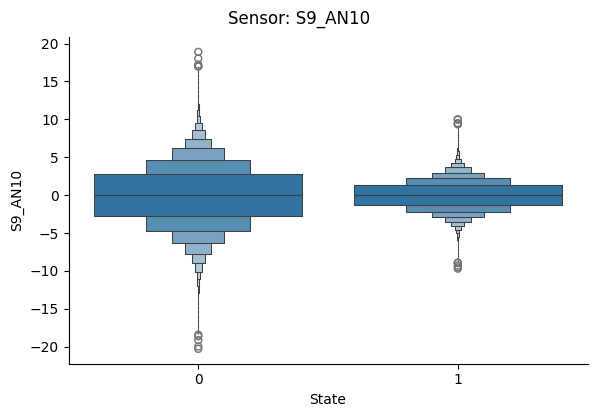

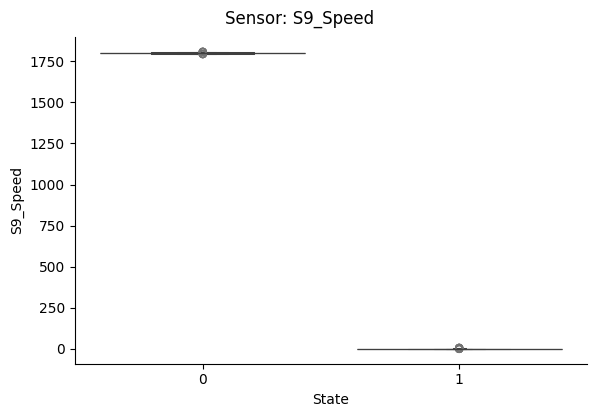

In [12]:
for sensor in feature_cols:
    sns.catplot(
        data=data_scaled,
        x='State', y=sensor,
        kind='boxen',
        height=4, aspect=1.5
    ).fig.suptitle(f'Sensor: {sensor}', y=1.03)

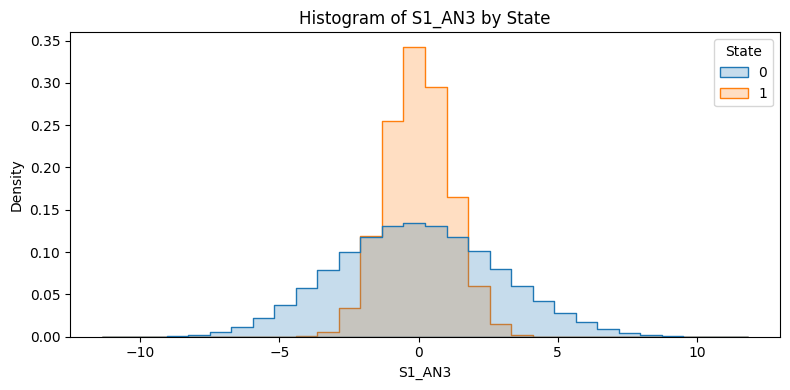

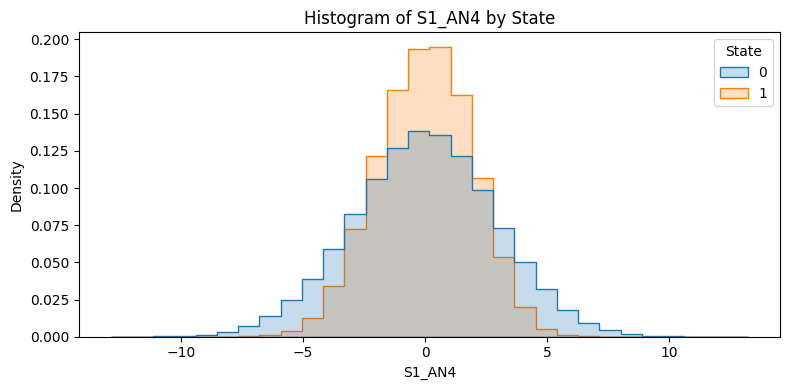

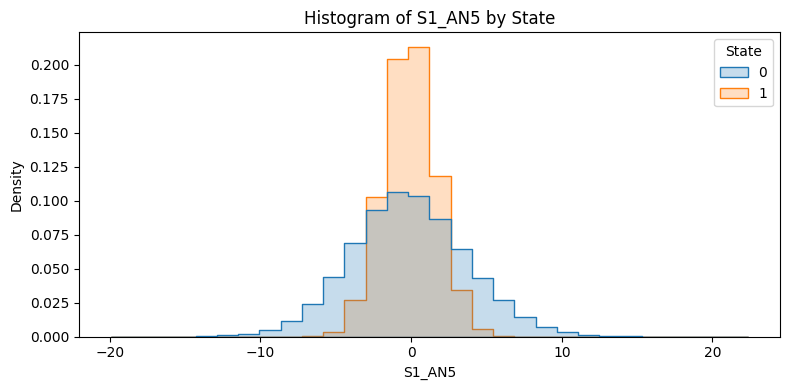

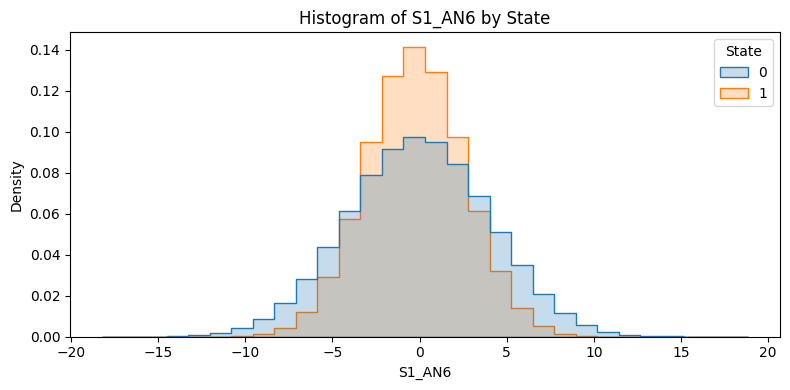

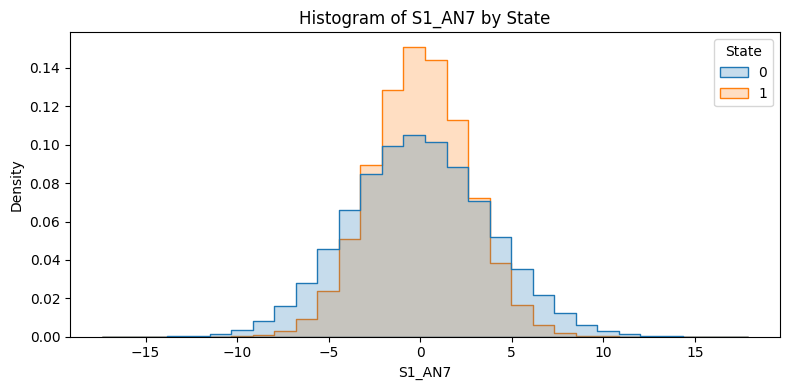

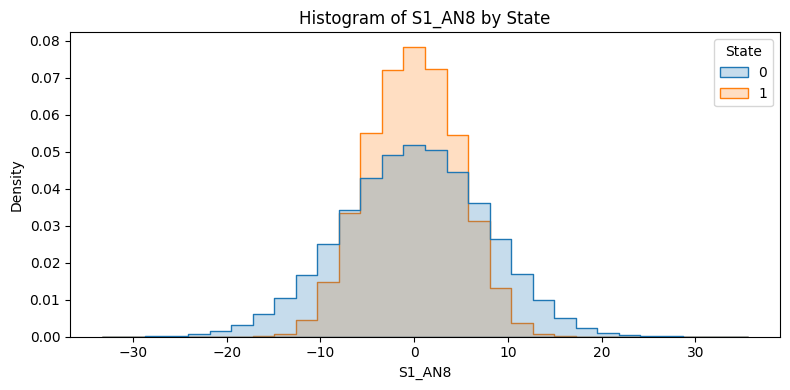

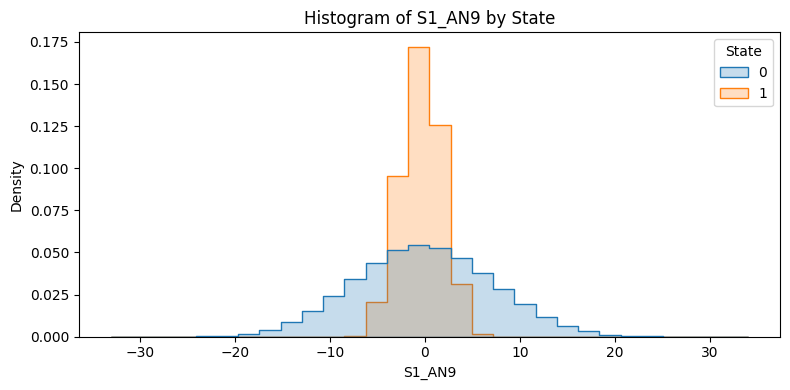

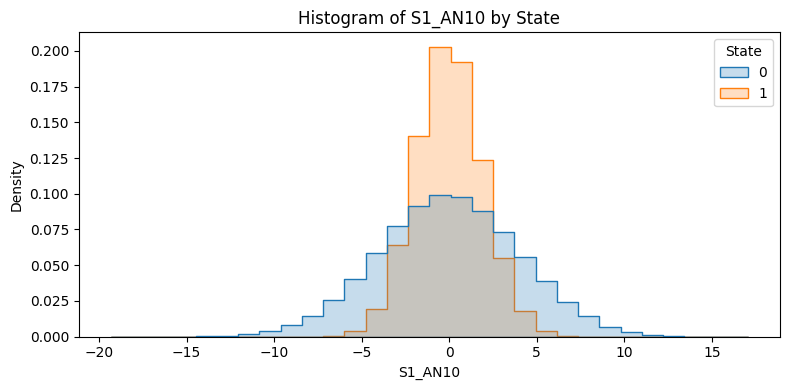

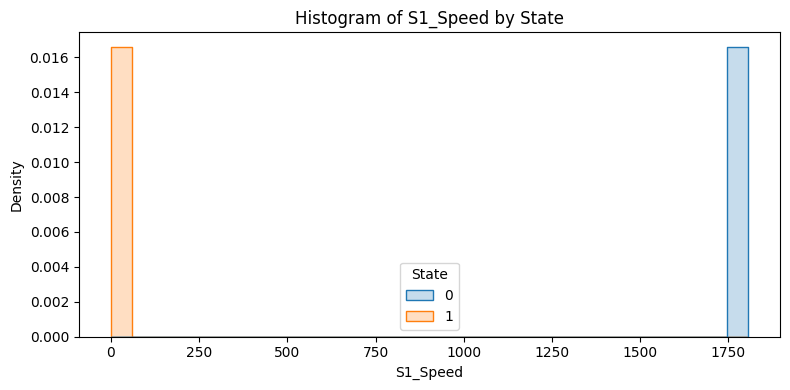

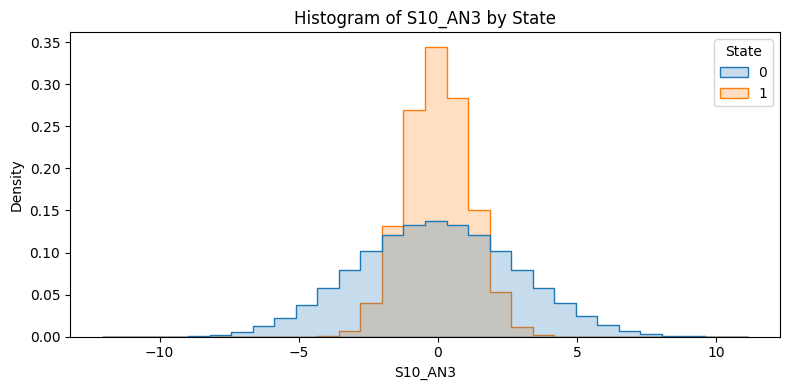

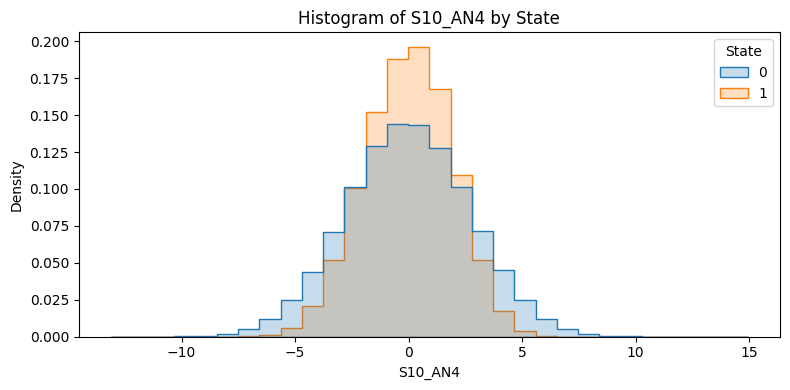

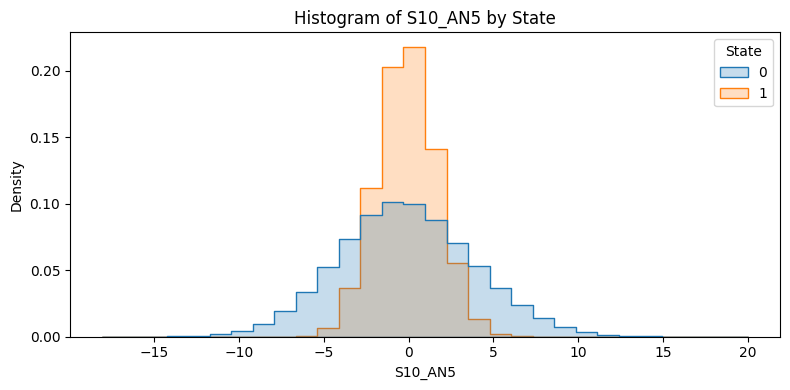

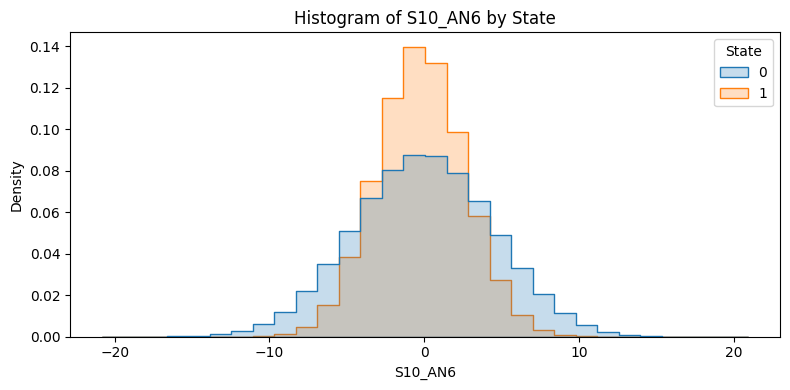

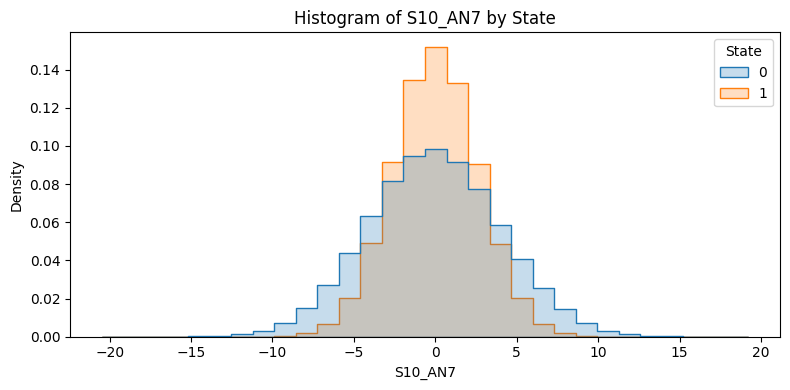

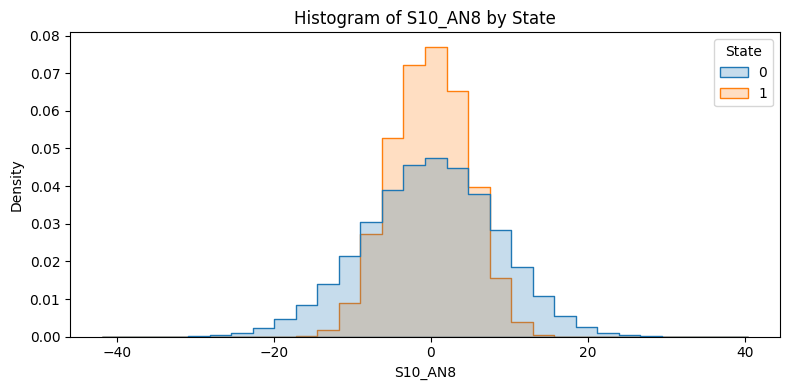

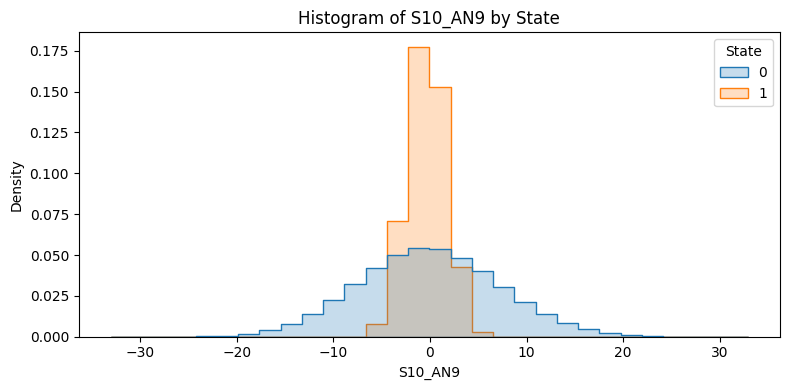

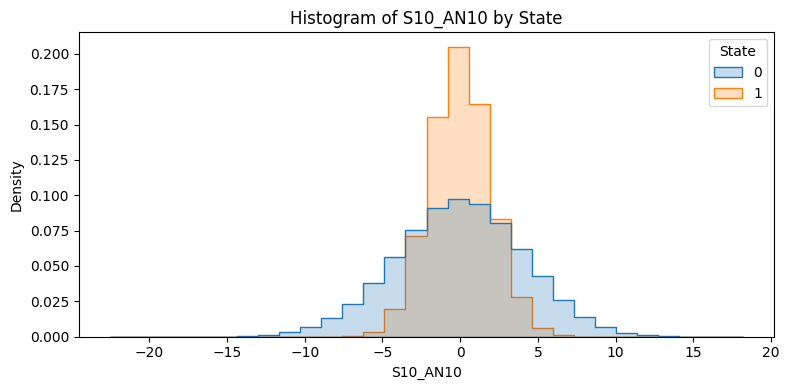

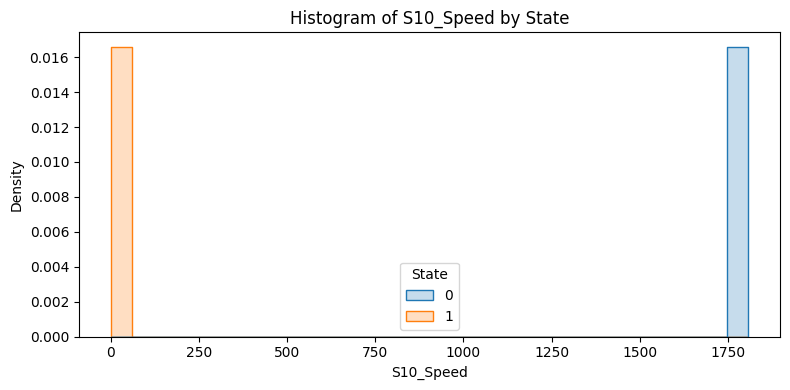

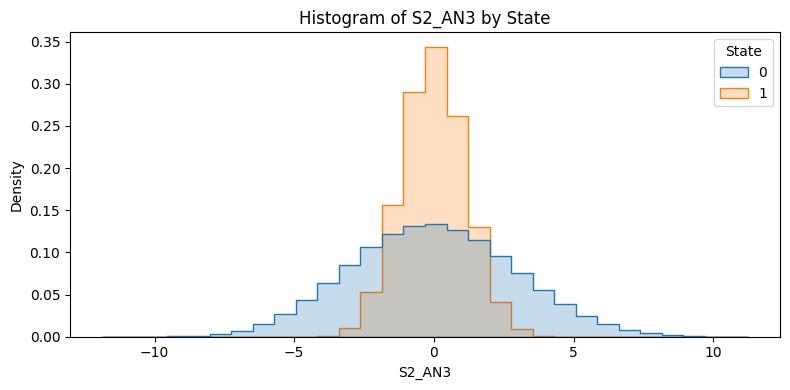

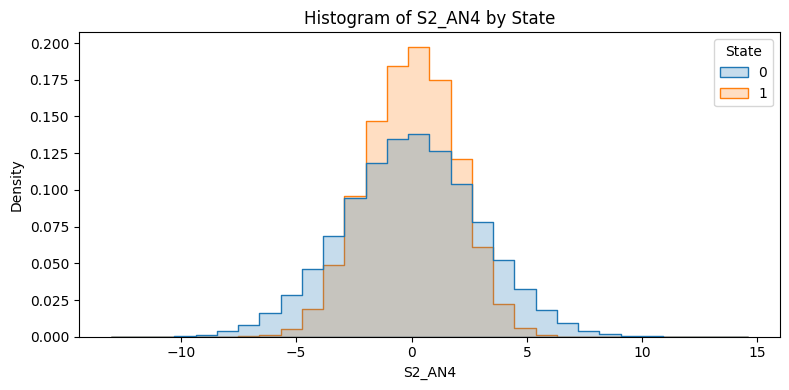

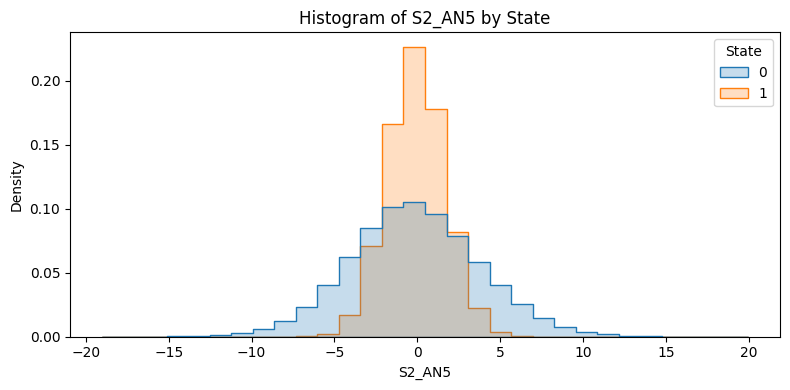

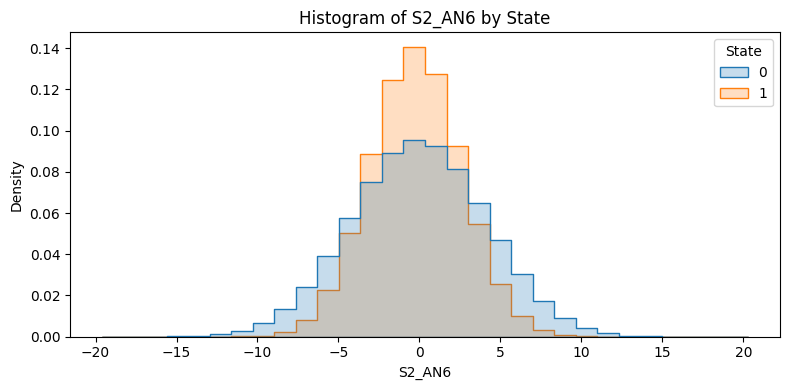

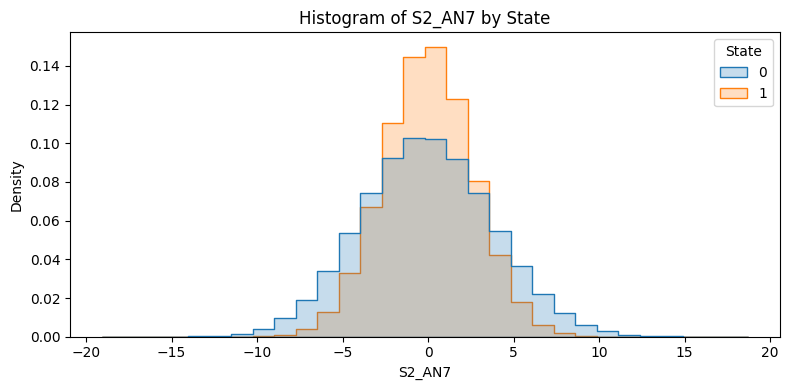

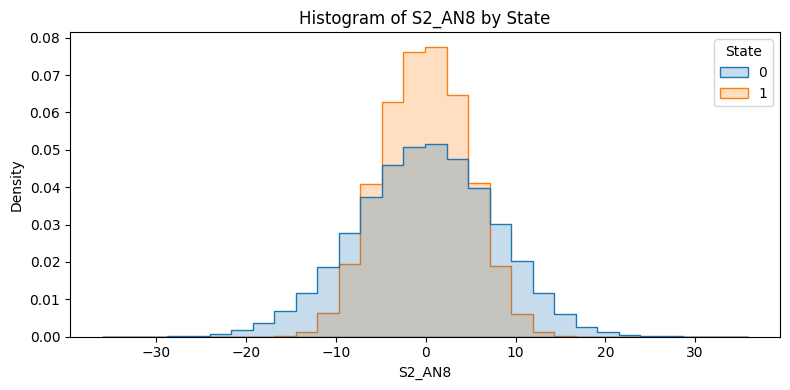

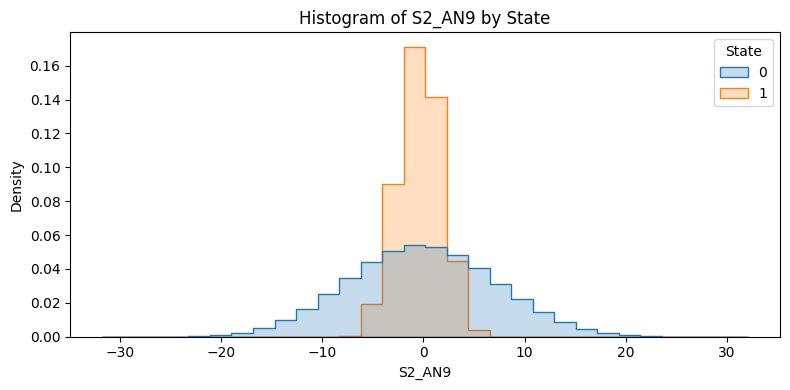

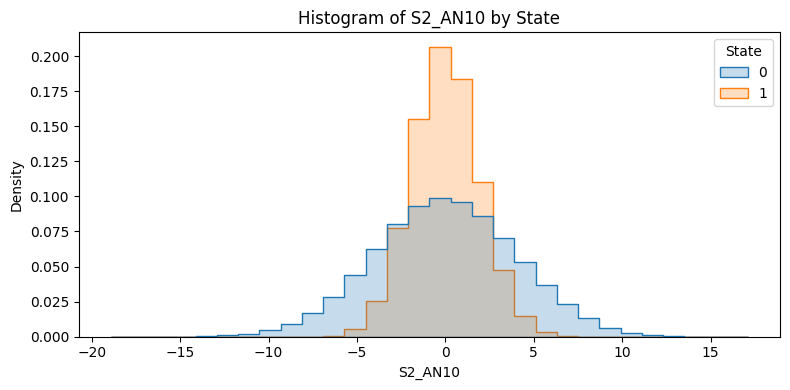

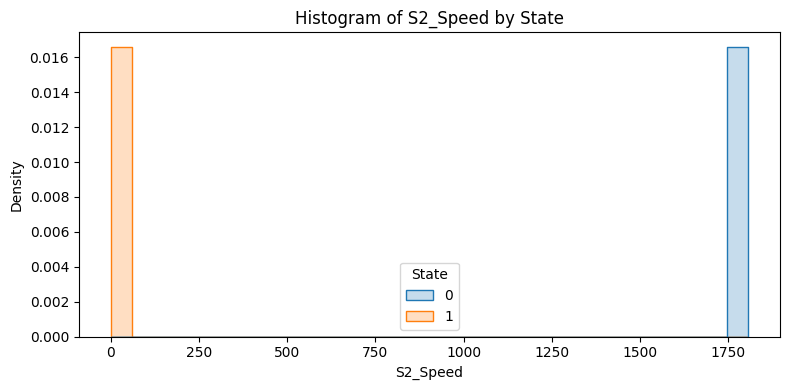

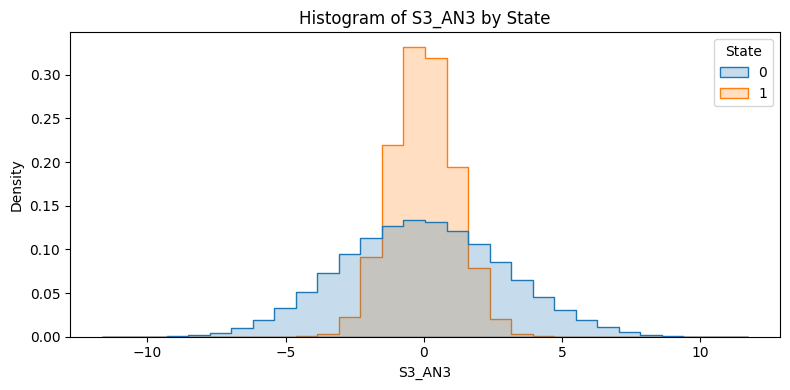

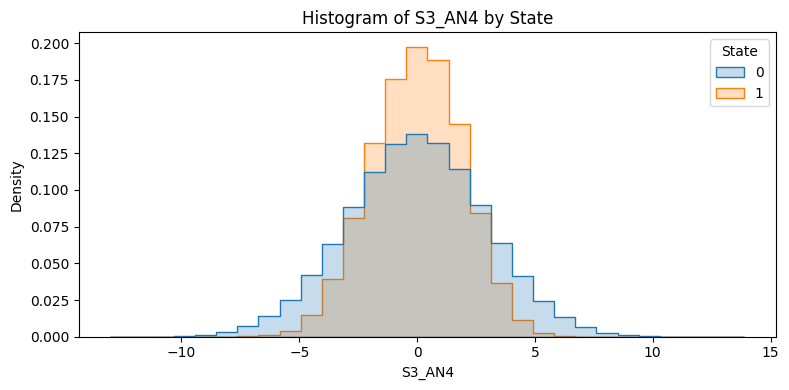

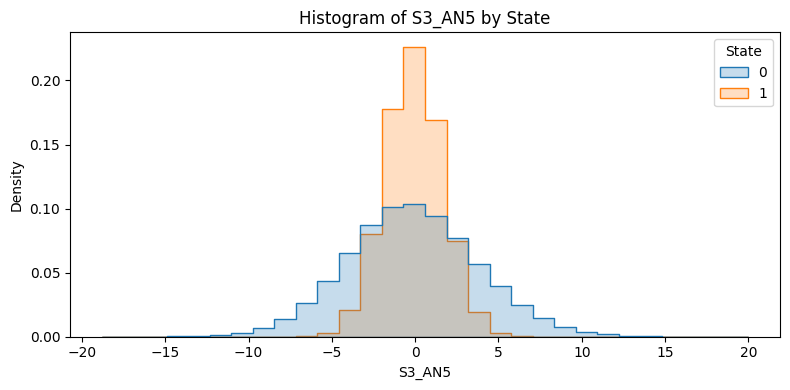

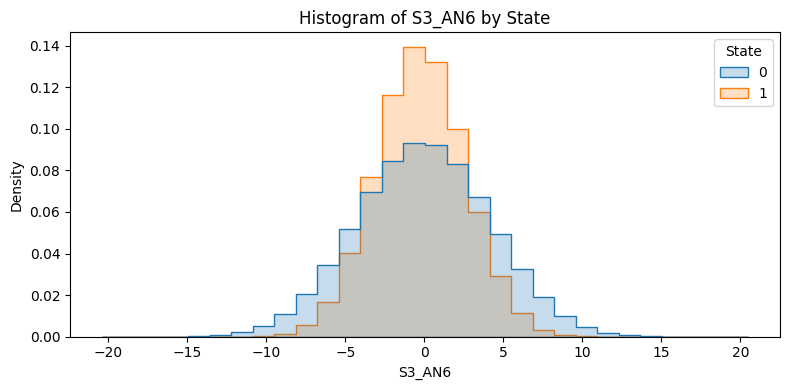

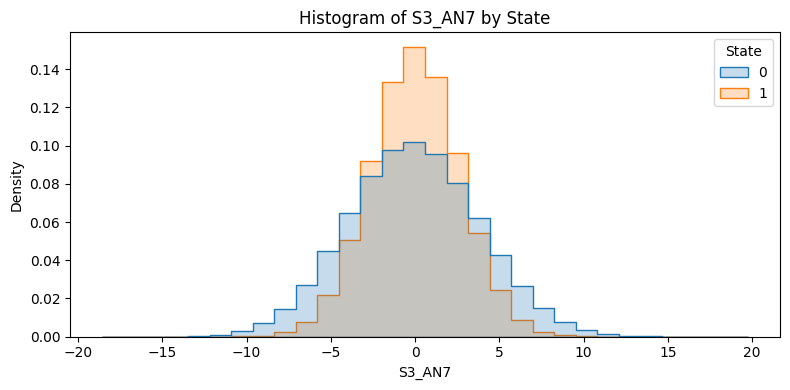

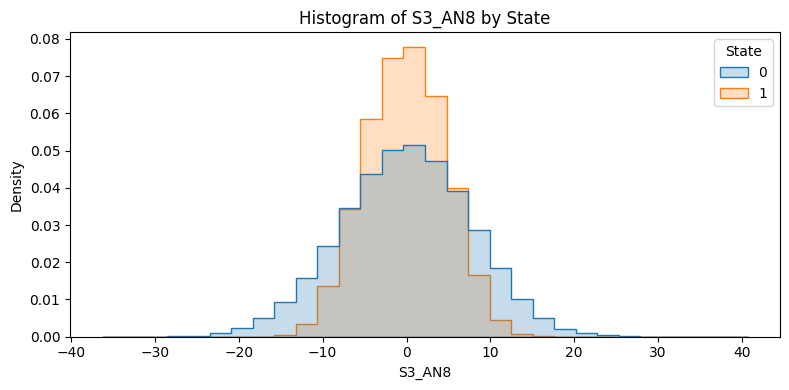

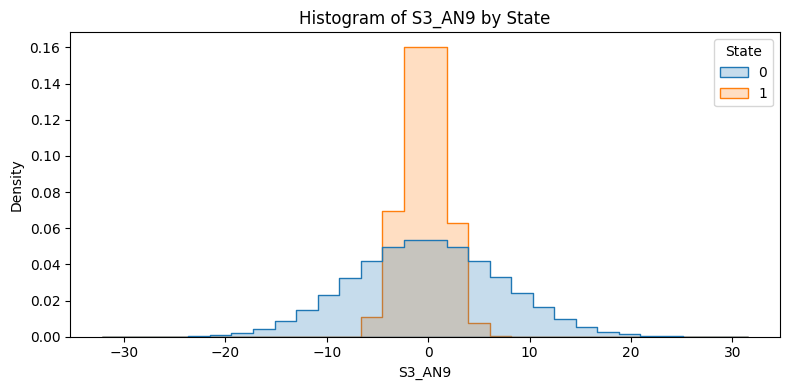

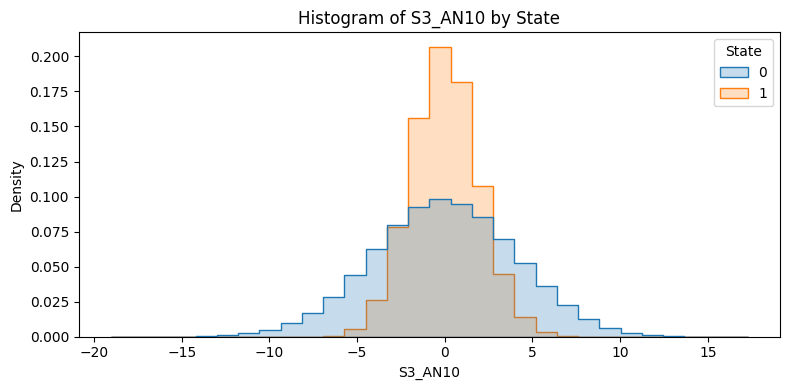

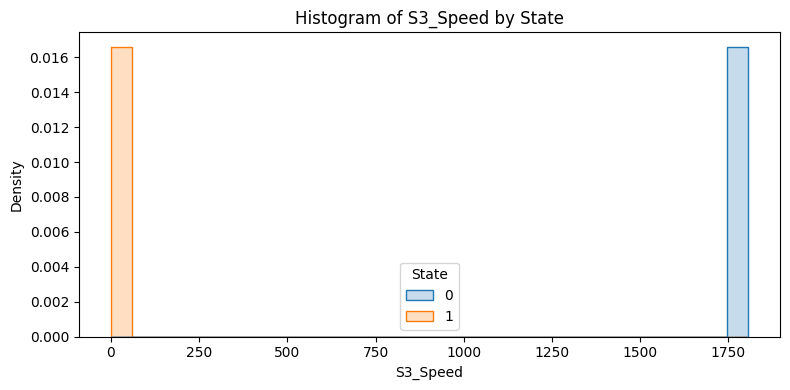

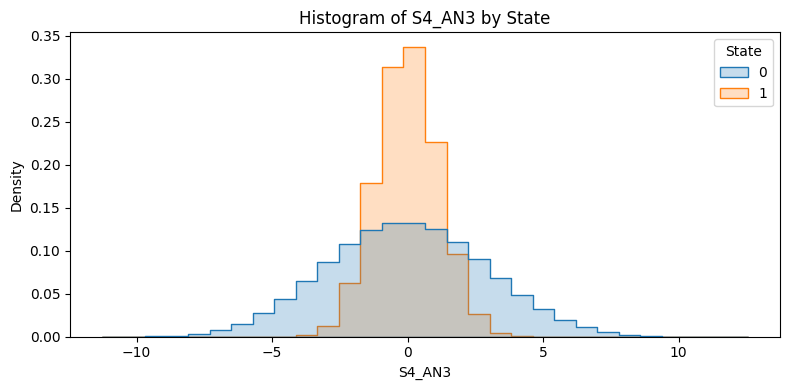

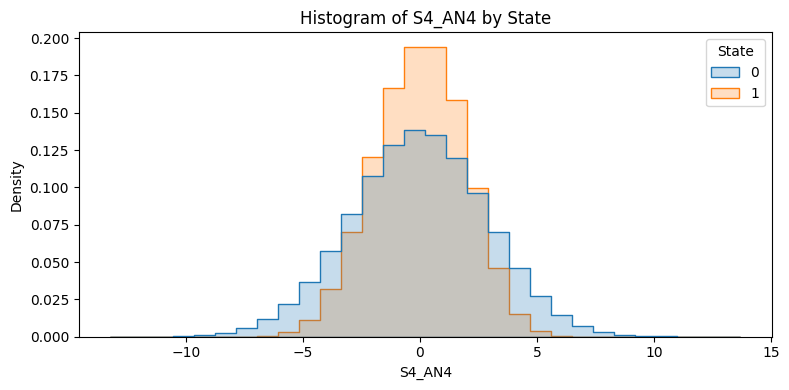

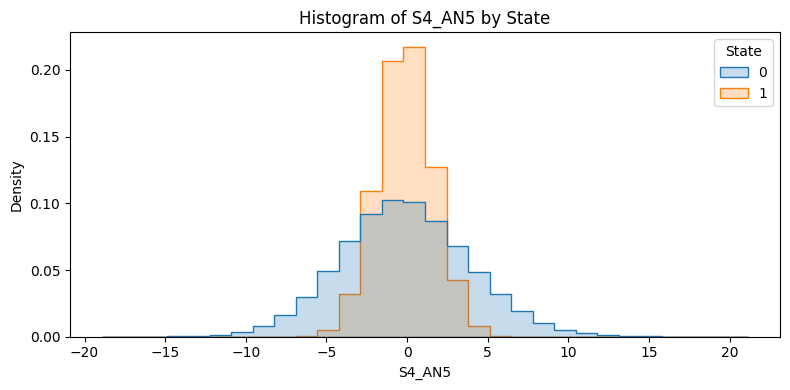

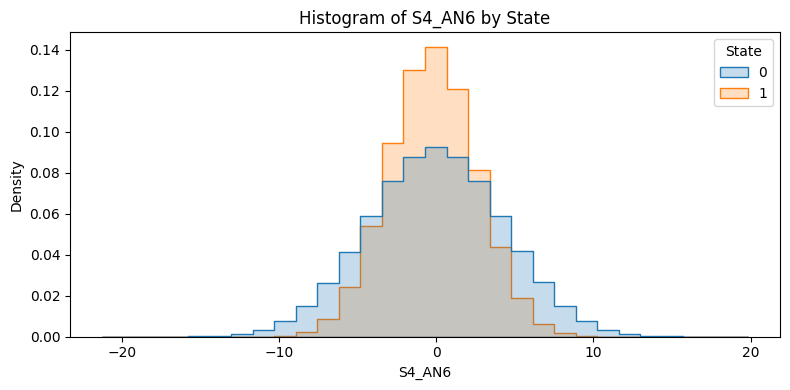

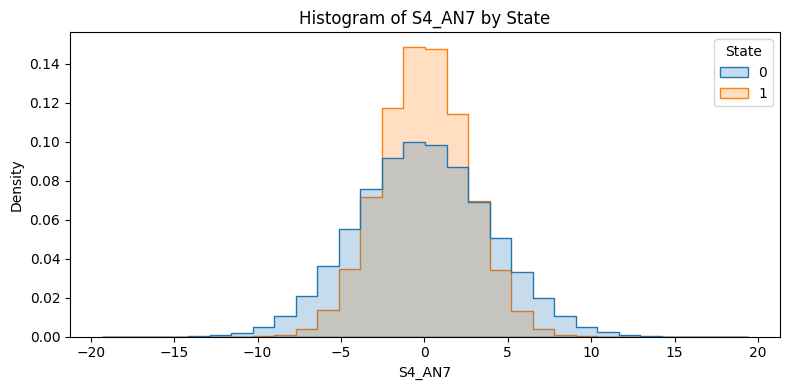

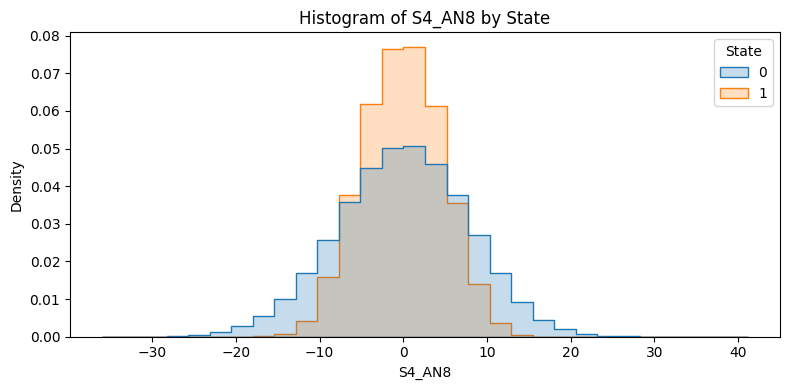

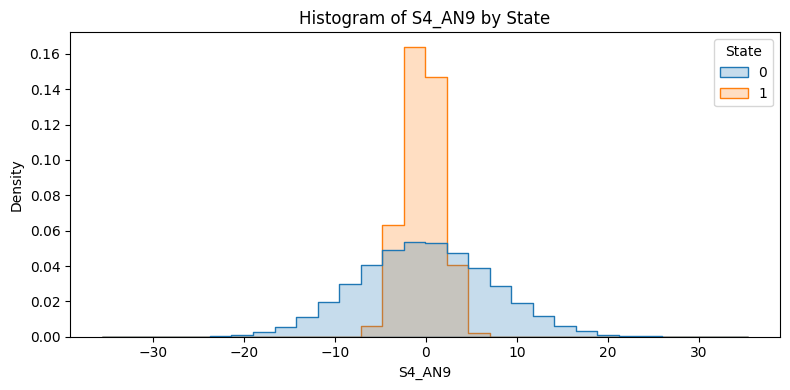

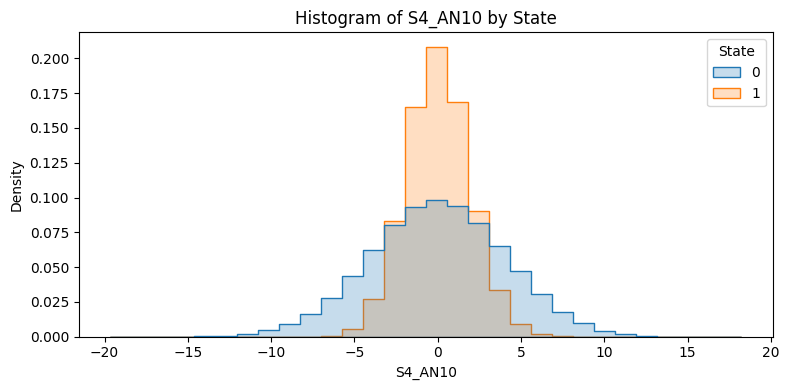

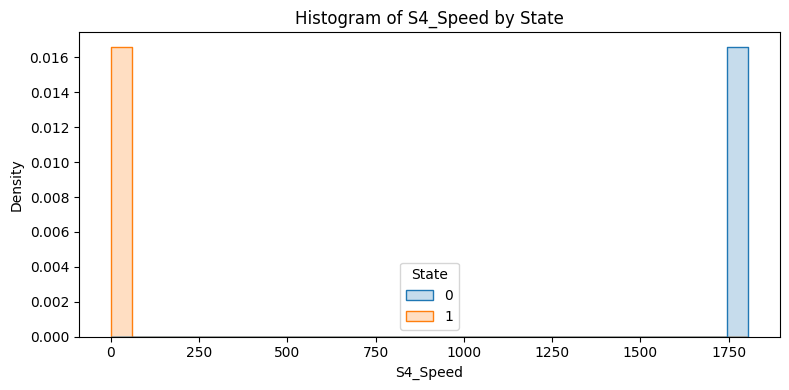

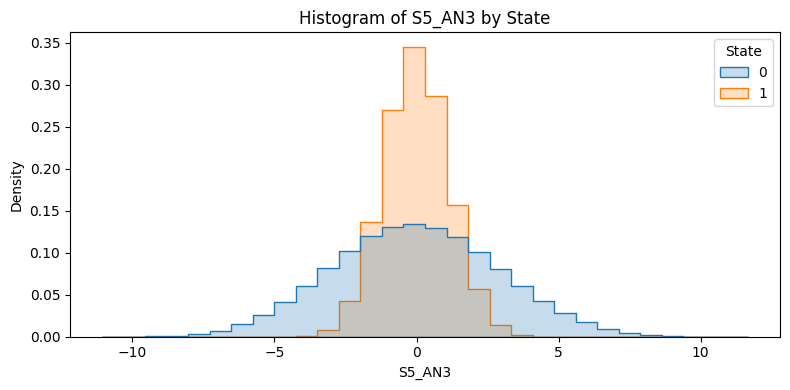

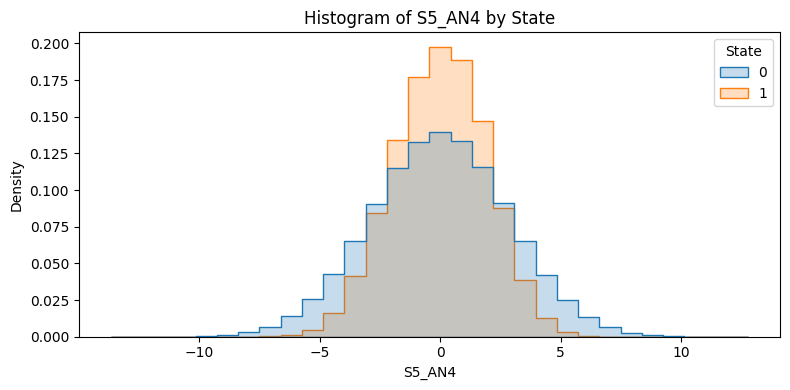

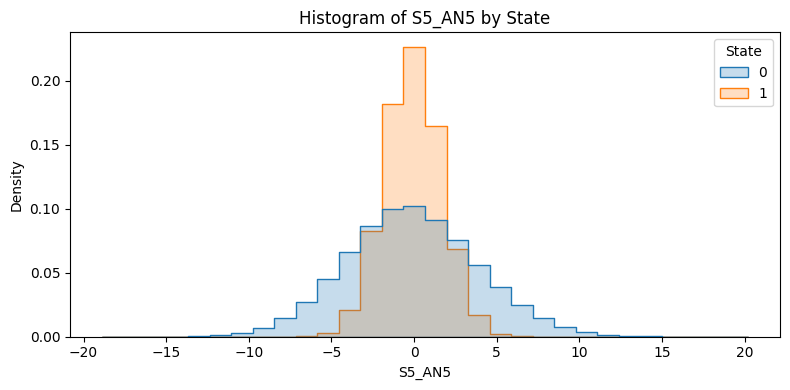

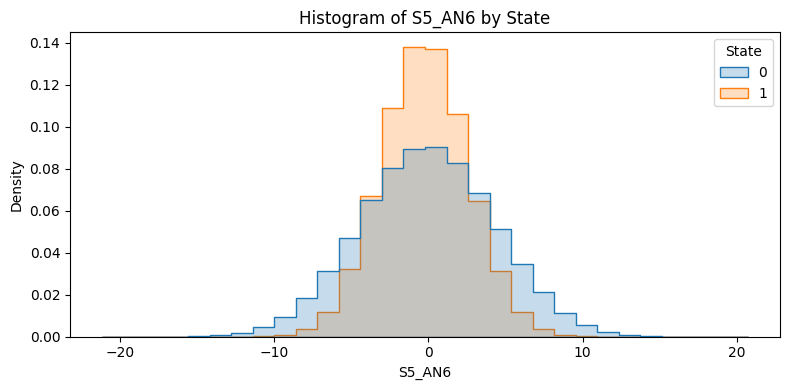

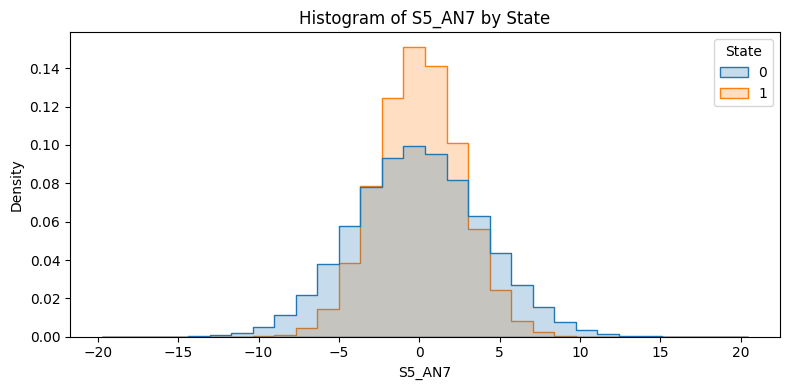

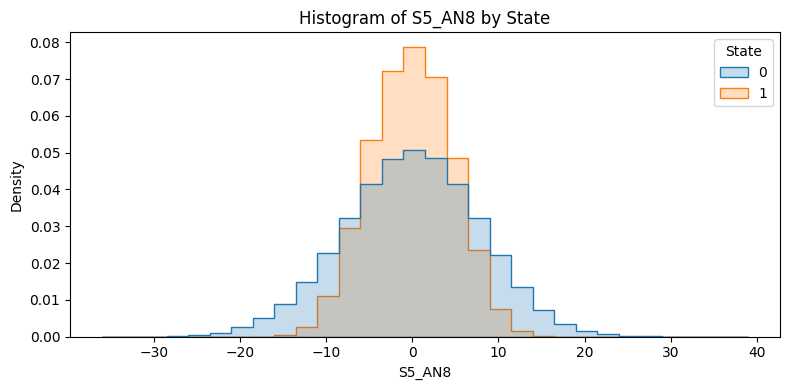

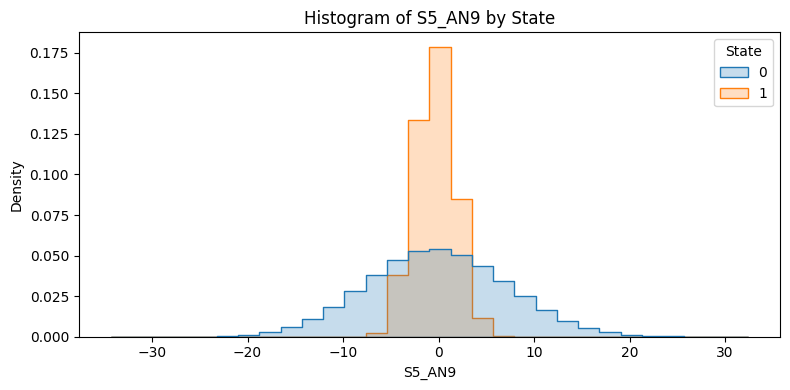

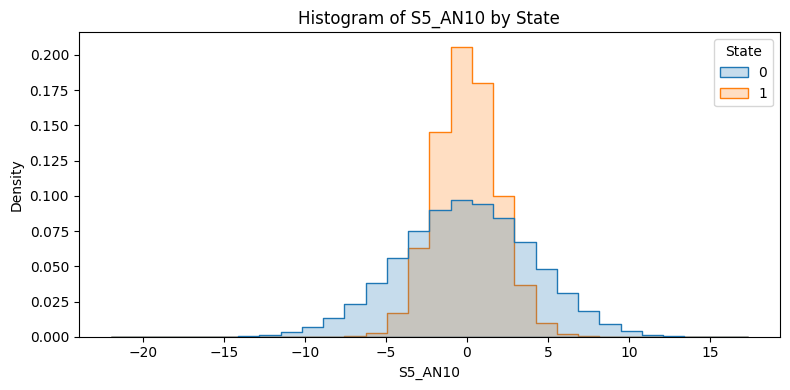

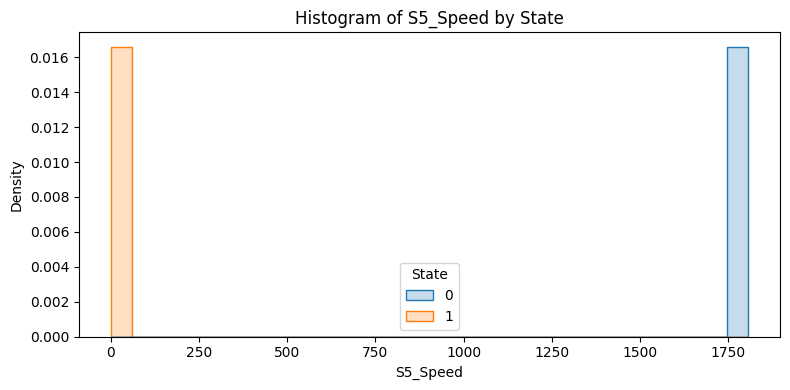

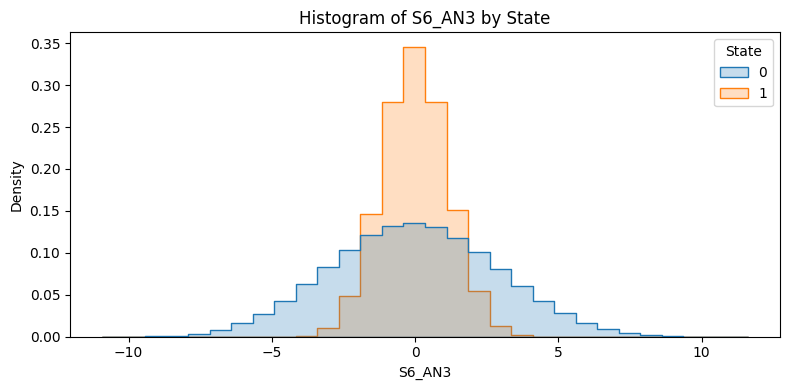

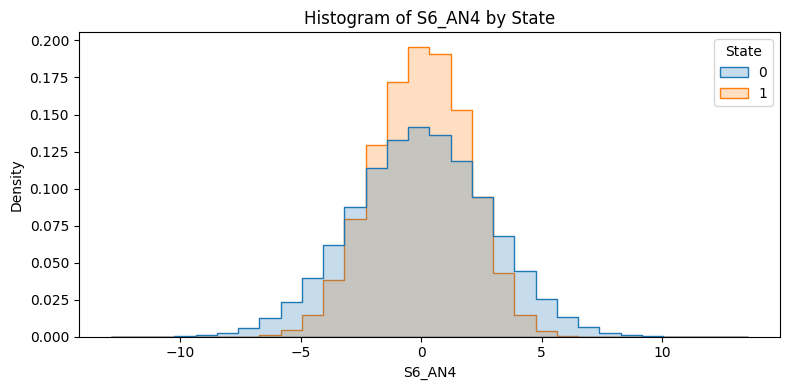

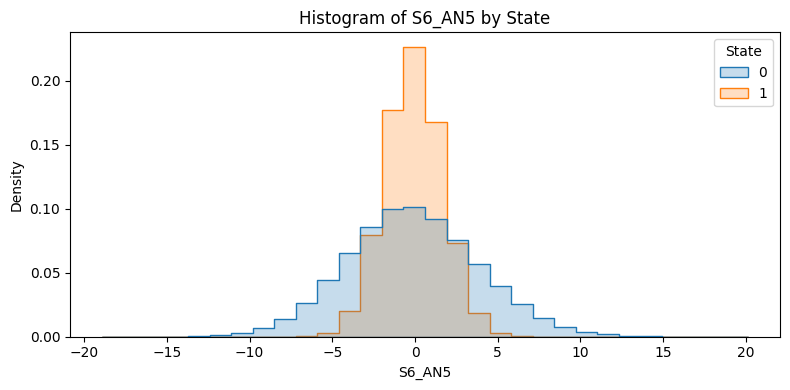

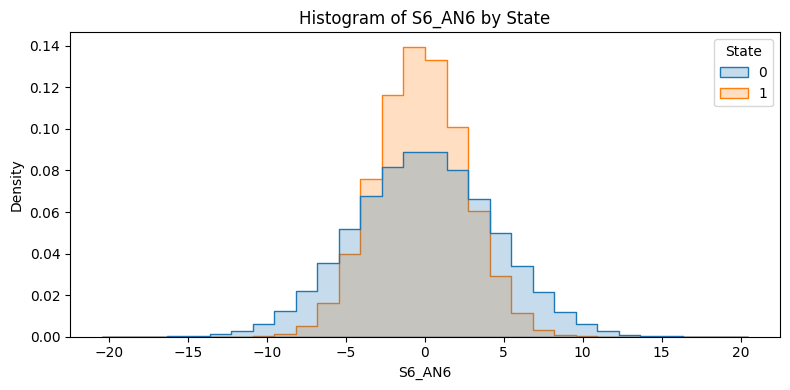

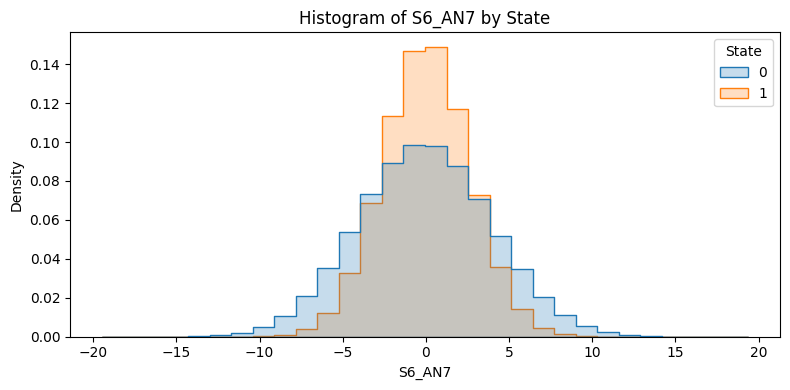

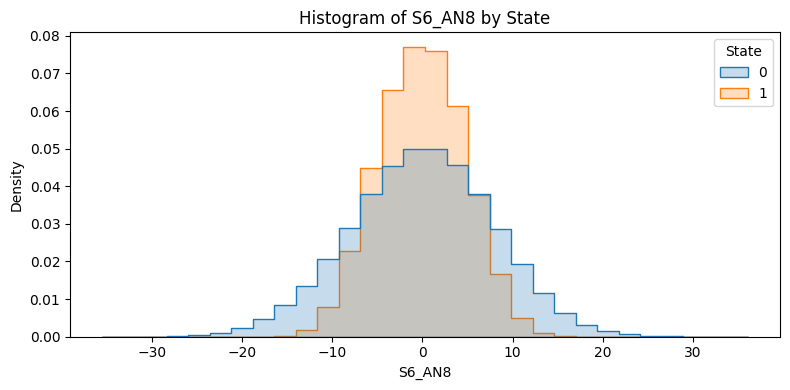

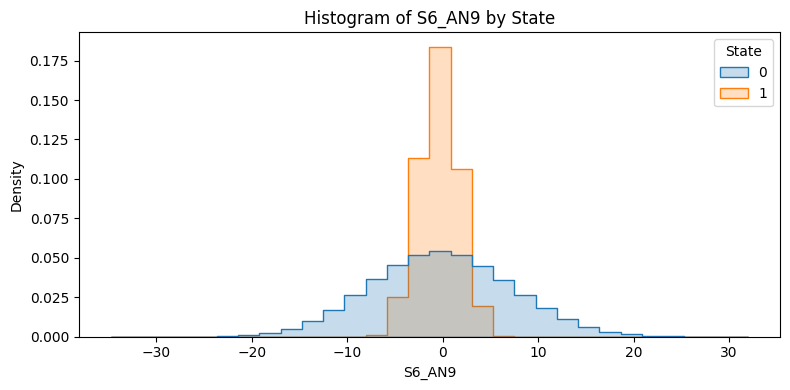

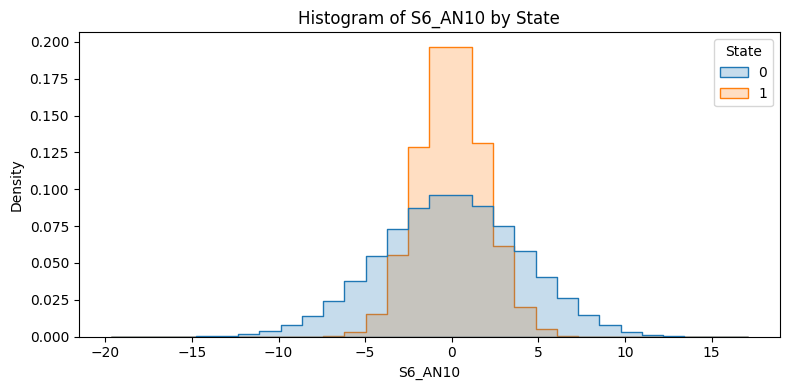

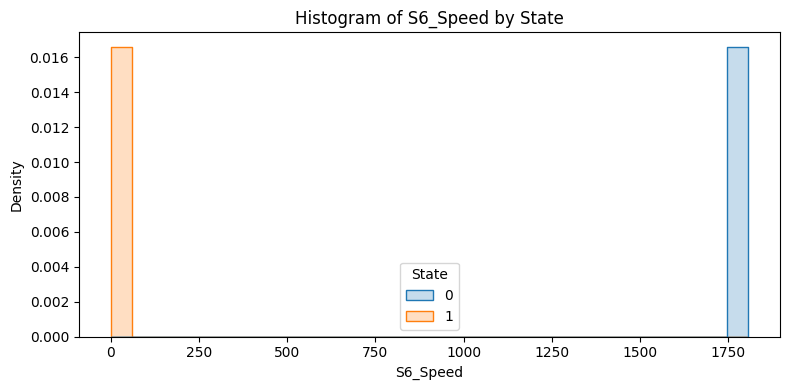

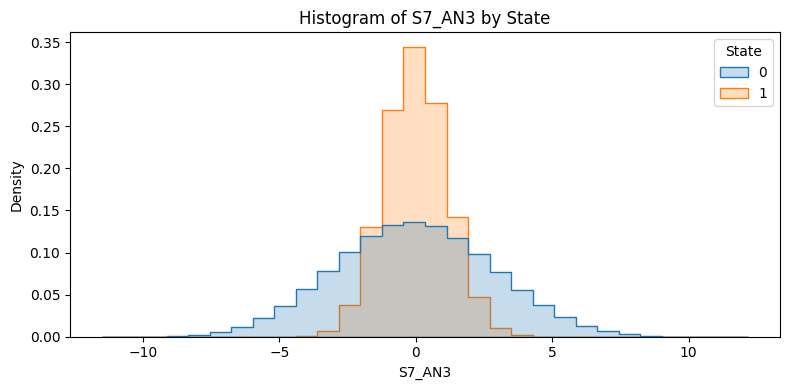

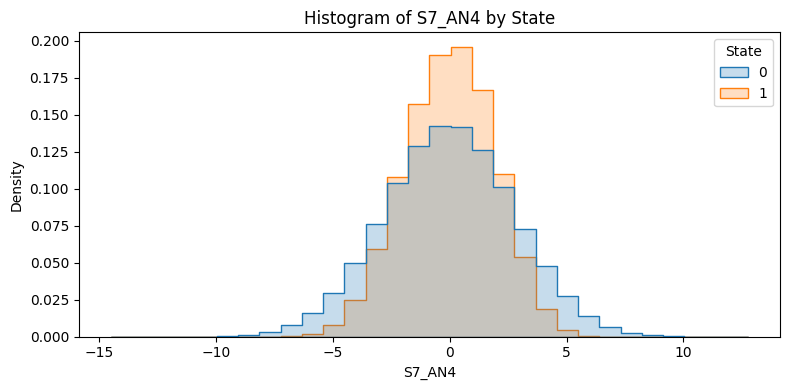

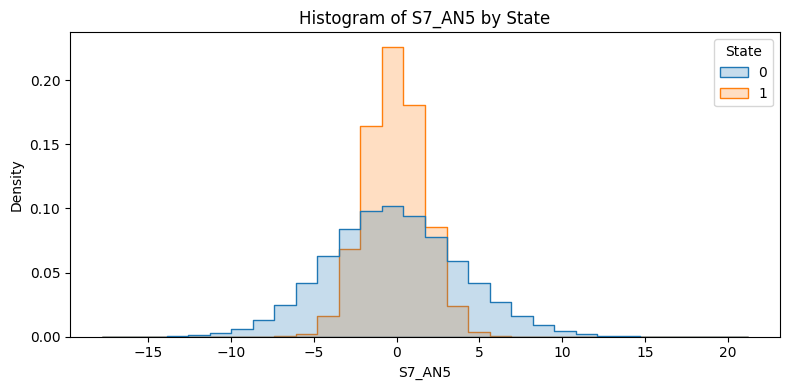

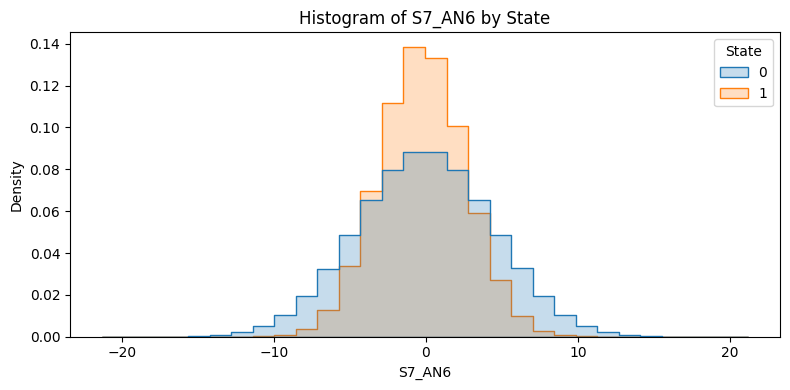

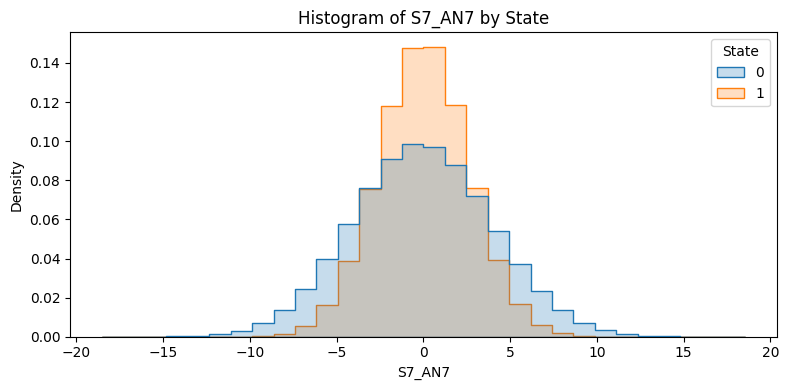

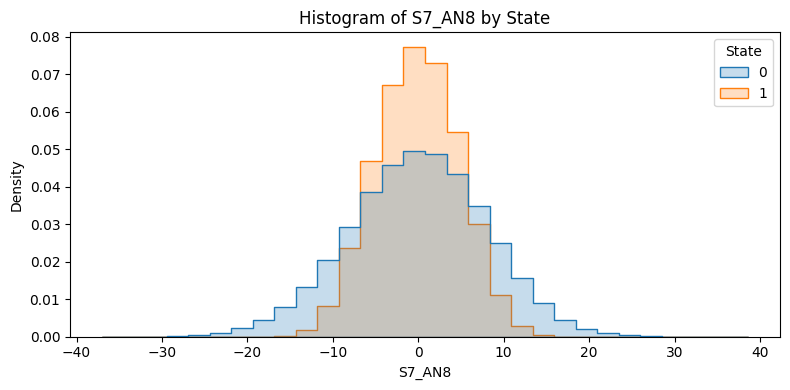

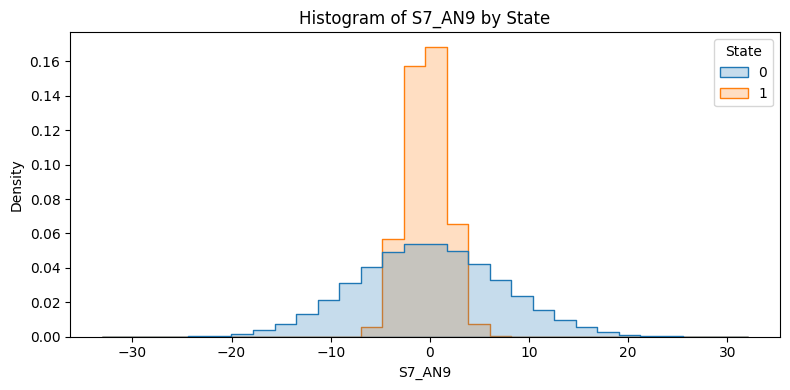

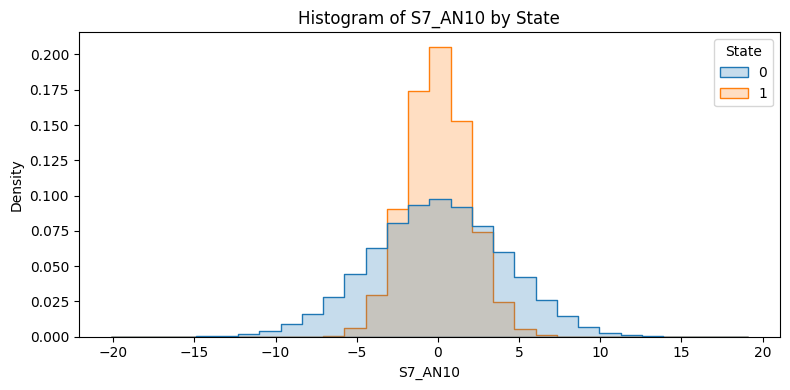

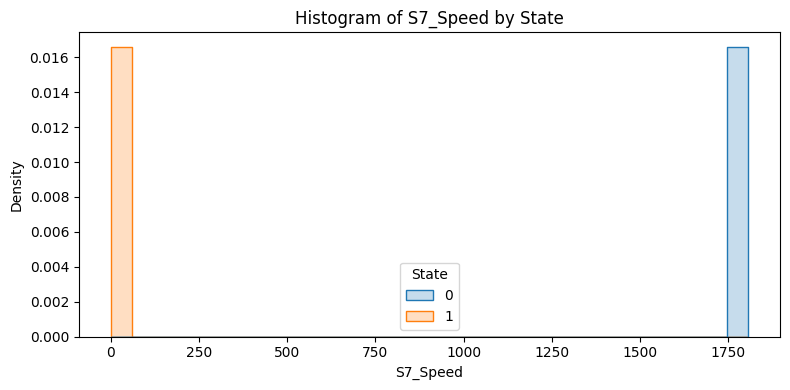

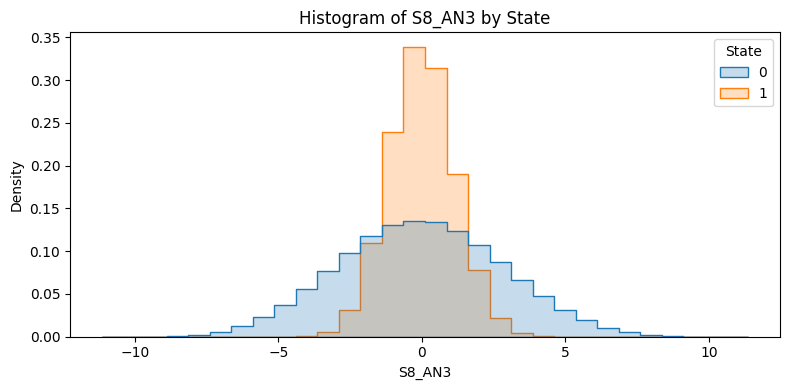

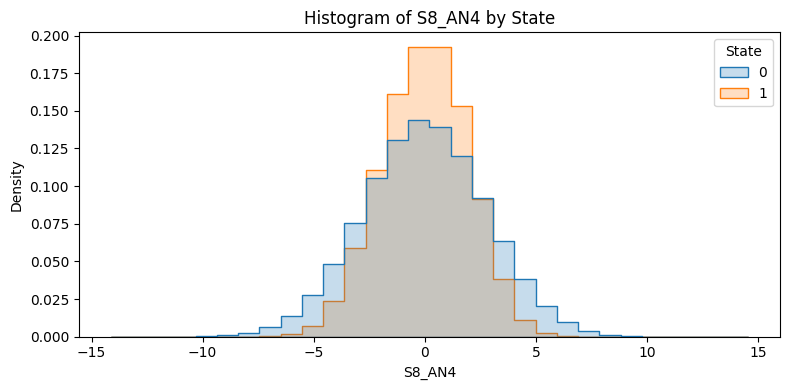

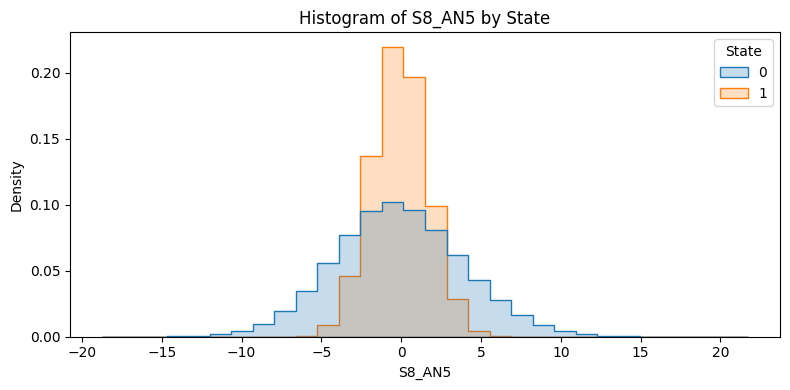

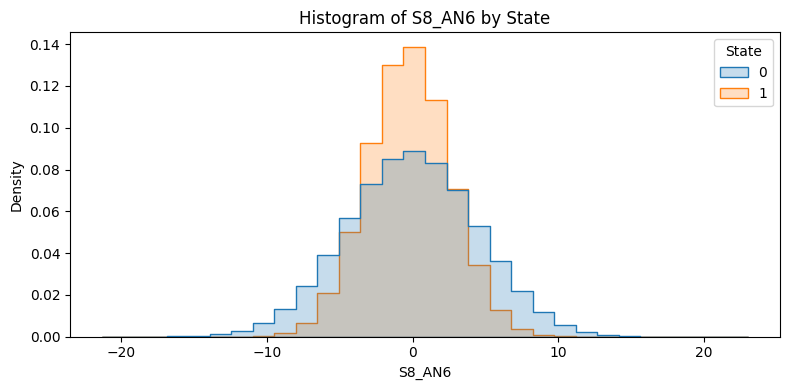

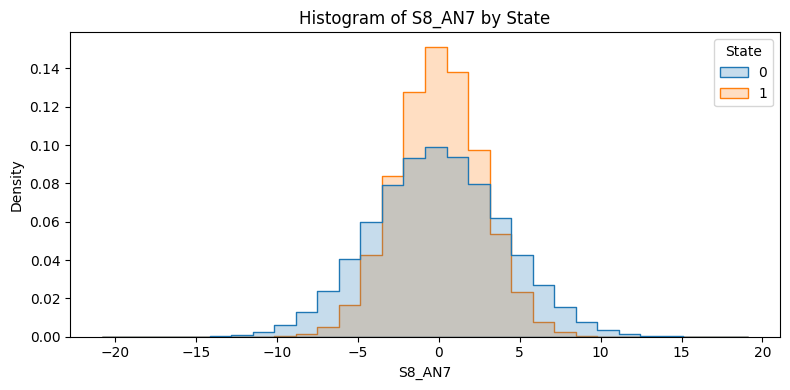

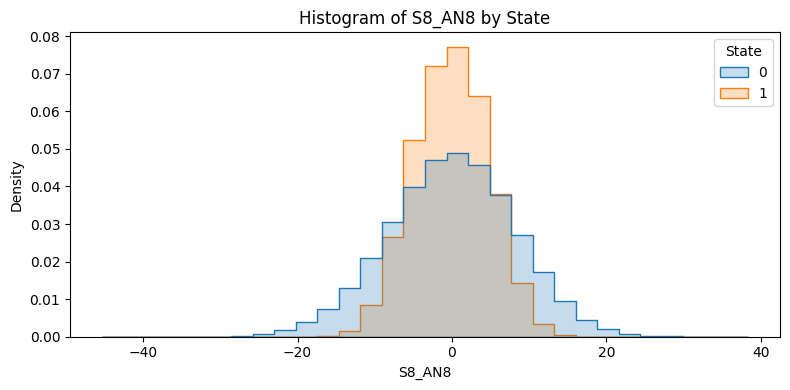

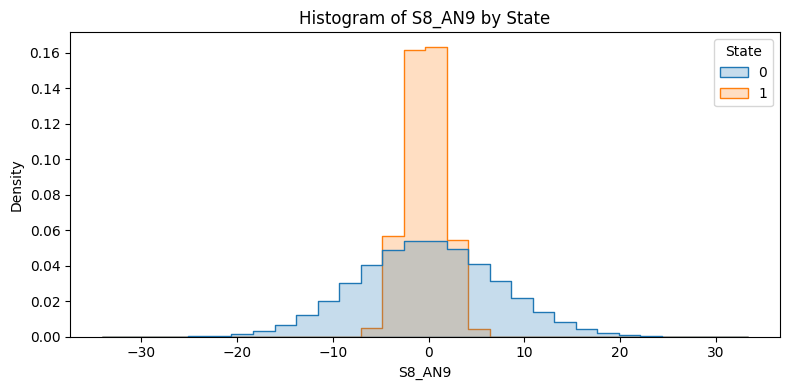

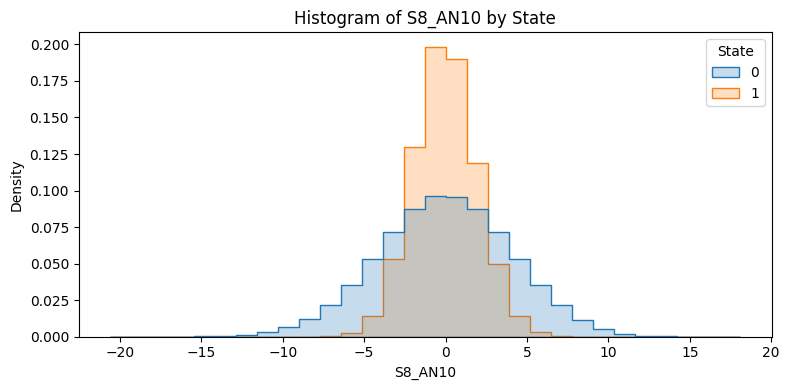

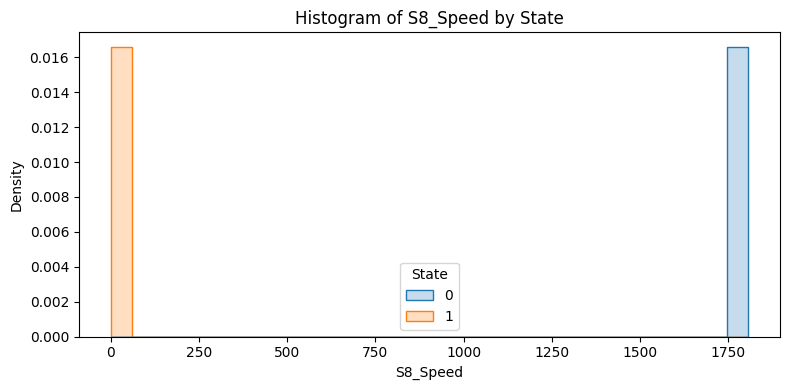

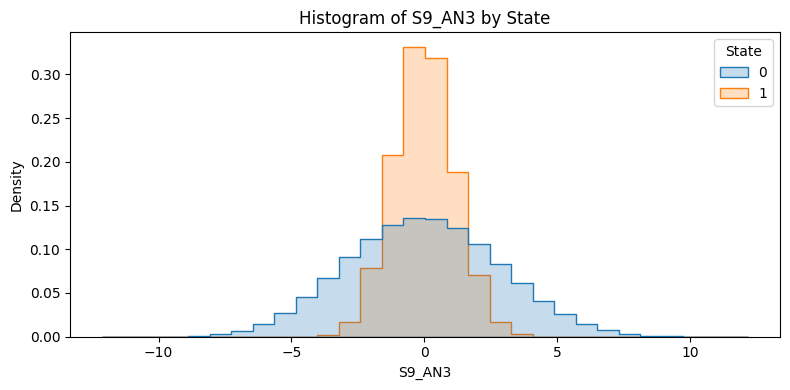

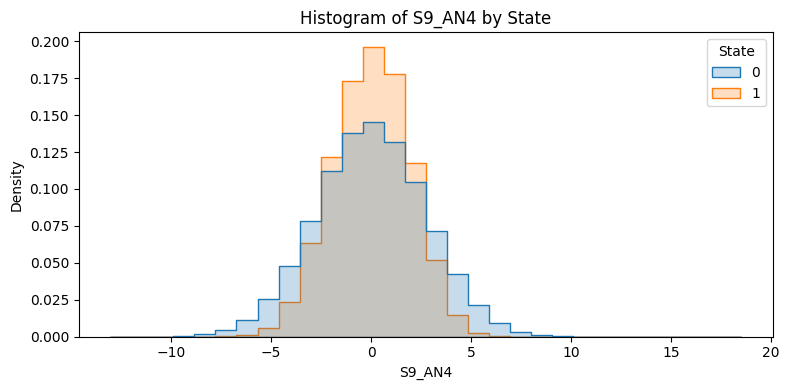

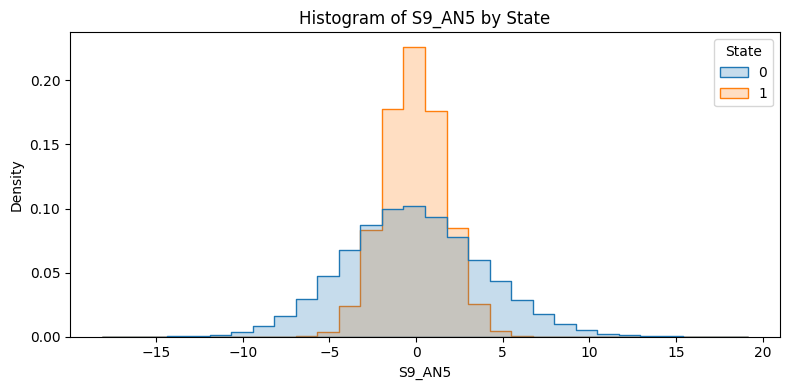

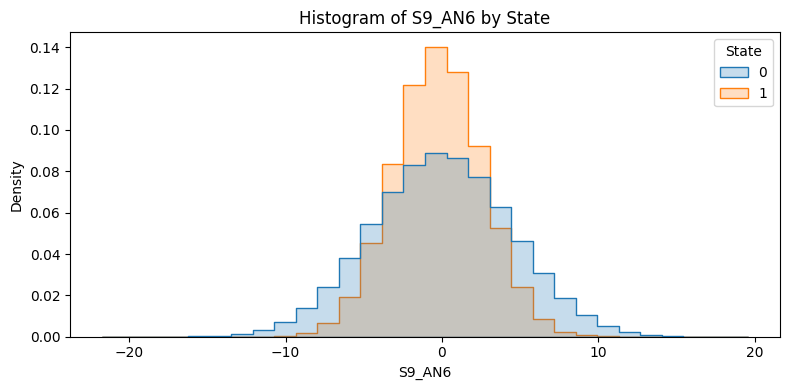

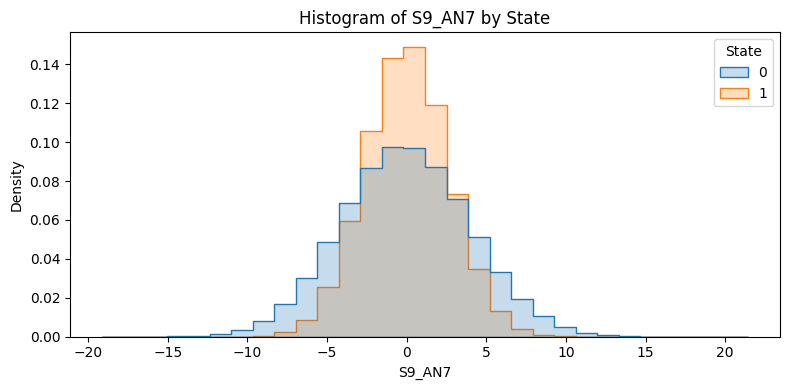

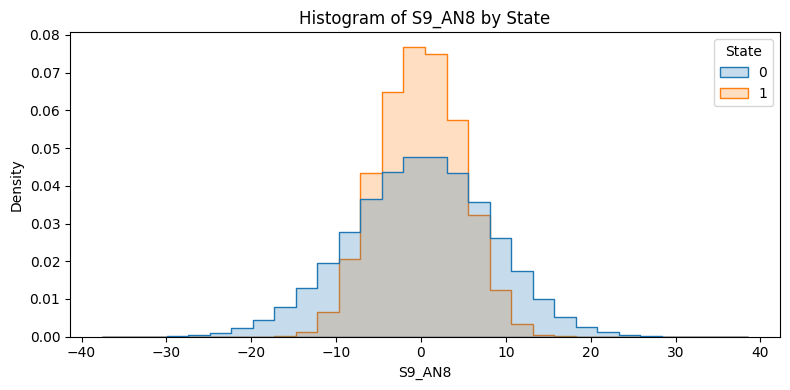

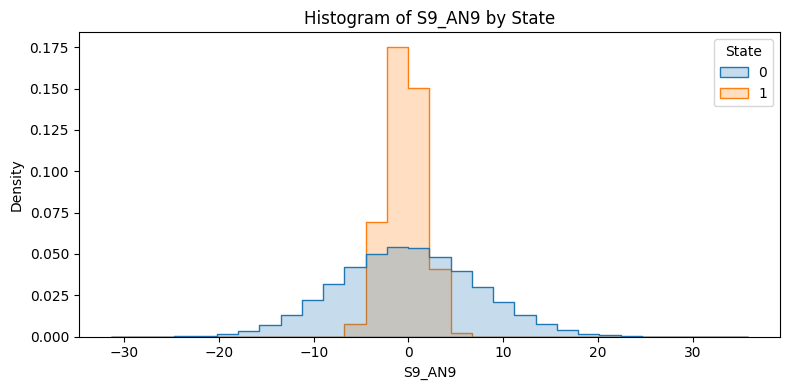

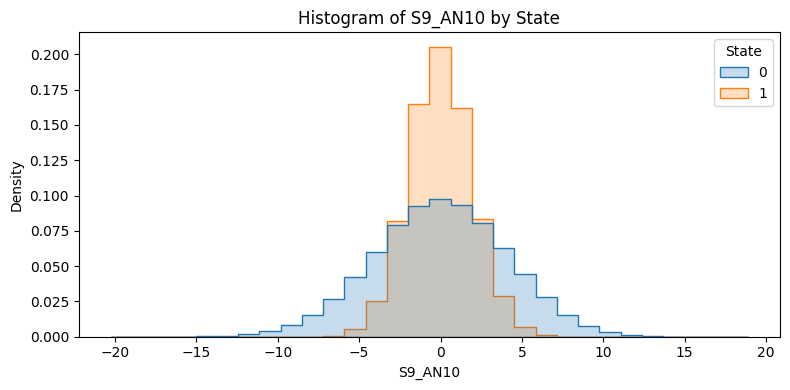

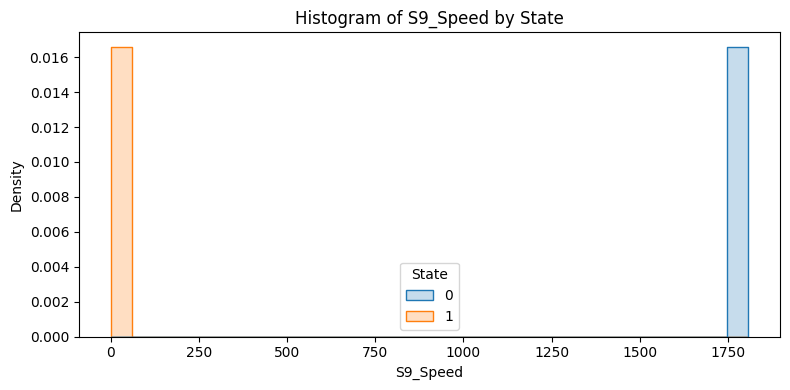

In [15]:
n = len(feature_cols)
for col in feature_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=data_scaled, x=col, hue='State', bins=30, kde=False, element='step', stat='density', common_norm=False)
    plt.title(f'Histogram of {col} by State')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.tight_layout()
    plt.show()

In [20]:
from scipy.stats import f_oneway
features_with_no_dependancy = []
imp_features = []
useless_features = []
for i in range(0, len(feature_cols)):
    # Group the numerical variable by target class
    groups = [group[feature_cols[i]].values for State, group in data_scaled.groupby('State')]
    
    # Run ANOVA
    f_stat, p_value = f_oneway(*groups)  
    
    
    # Visualize
    #sns.boxplot(x='State', y='S1_Speed', data=dfGbxData)
    #plt.title('Speed vs State correlation')
    #plt.show()
    
    if p_value < 0.05:
        print("Significant dependency between " + feature_cols[i] + " and State.")
        imp_features.append(feature_cols[i])
    else:
        print("No significant dependency between " + feature_cols[i] + " and State.")
        useless_features.append(feature_cols[i])
    print(f"F-statistic: {f_stat:.4f}")
    print(f"p-value: {p_value:.4f}")


Significant dependency between S1_AN3 and State.
F-statistic: 170.3617
p-value: 0.0000
Significant dependency between S1_AN4 and State.
F-statistic: 53.9521
p-value: 0.0000
Significant dependency between S1_AN5 and State.
F-statistic: 190.7267
p-value: 0.0000
Significant dependency between S1_AN6 and State.
F-statistic: 3917.8374
p-value: 0.0000
Significant dependency between S1_AN7 and State.
F-statistic: 632.3136
p-value: 0.0000
Significant dependency between S1_AN8 and State.
F-statistic: 62.5938
p-value: 0.0000
Significant dependency between S1_AN9 and State.
F-statistic: 3826.1114
p-value: 0.0000
Significant dependency between S1_AN10 and State.
F-statistic: 58.4961
p-value: 0.0000
Significant dependency between S1_Speed and State.
F-statistic: 797259002738.7603
p-value: 0.0000
Significant dependency between S10_AN3 and State.
F-statistic: 199.4957
p-value: 0.0000
Significant dependency between S10_AN4 and State.
F-statistic: 68.4555
p-value: 0.0000
Significant dependency between 

In [21]:
print(imp_features)
print(useless_features)

['S1_AN3', 'S1_AN4', 'S1_AN5', 'S1_AN6', 'S1_AN7', 'S1_AN8', 'S1_AN9', 'S1_AN10', 'S1_Speed', 'S10_AN3', 'S10_AN4', 'S10_AN5', 'S10_AN6', 'S10_AN7', 'S10_AN8', 'S10_AN9', 'S10_AN10', 'S10_Speed', 'S2_AN3', 'S2_AN4', 'S2_AN5', 'S2_AN6', 'S2_AN7', 'S2_AN8', 'S2_AN9', 'S2_AN10', 'S2_Speed', 'S3_AN3', 'S3_AN4', 'S3_AN5', 'S3_AN6', 'S3_AN7', 'S3_AN8', 'S3_AN9', 'S3_AN10', 'S3_Speed', 'S4_AN3', 'S4_AN4', 'S4_AN5', 'S4_AN6', 'S4_AN7', 'S4_AN8', 'S4_AN9', 'S4_AN10', 'S4_Speed', 'S5_AN3', 'S5_AN4', 'S5_AN5', 'S5_AN6', 'S5_AN7', 'S5_AN8', 'S5_AN9', 'S5_AN10', 'S5_Speed', 'S6_AN3', 'S6_AN4', 'S6_AN5', 'S6_AN6', 'S6_AN7', 'S6_AN8', 'S6_AN9', 'S6_AN10', 'S6_Speed', 'S7_AN3', 'S7_AN4', 'S7_AN5', 'S7_AN6', 'S7_AN7', 'S7_AN8', 'S7_AN9', 'S7_AN10', 'S7_Speed', 'S8_AN3', 'S8_AN4', 'S8_AN5', 'S8_AN6', 'S8_AN7', 'S8_AN8', 'S8_AN9', 'S8_AN10', 'S8_Speed', 'S9_AN3', 'S9_AN4', 'S9_AN5', 'S9_AN6', 'S9_AN7', 'S9_AN8', 'S9_AN9', 'S9_AN10', 'S9_Speed']
[]


In [24]:
xModel = data_scaled[imp_features]
yModel = dfGbxData['State']
print(xModel.shape)
print(yModel.shape)

(4800000, 90)
(4800000,)


In [26]:
# Train Test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    xModel, yModel,
    train_size=0.8,
    random_state=42,
    stratify=yModel
)

In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import AdaBoostClassifier

In [28]:
# Standarise features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# initialize the adaBoost classifier with a base estimator
baseEstimator = RandomForestClassifier(n_estimators=100, random_state=42)
adaboost_model = AdaBoostClassifier(estimator=baseEstimator,n_estimators=50,learning_rate=1.0,random_state=42)

# Train
adaboost_model.fit(X_train_scaled, y_train)

# Predict
y_pred = adaboost_model.predict(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Accuracy:", accuracy)
print("Classification Report:\n", report)


c:\users\anand.khare\documents\learnings\venv\lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    480000
           1       1.00      1.00      1.00    480000

    accuracy                           1.00    960000
   macro avg       1.00      1.00      1.00    960000
weighted avg       1.00      1.00      1.00    960000



In [29]:
from tpot import TPOTClassifier
tpot_td = TPOTClassifier(generations=5, random_state=42, max_time_mins=2)
tpot_td.fit(X_train, y_train)
print(f'Best accuracy score: {tpot_td.score(X_test, y_test):0.3%}')

pd.Series([
    model.split('(')[0]
    for model
    in tpot_td.evaluated_individuals_.keys()
]).value_counts()

Version 0.12.2 of tpot is outdated. Version 1.1.0 was released Thursday July 03, 2025.


Best accuracy score: 100.000%


GaussianNB                1
RandomForestClassifier    1
Name: count, dtype: int64